# 🛣️ Modelo de Inversión e Intervención para el Mejoramiento de la Vialidad Urbana
## Caso de Estudio: Comuna de San Miguel, Región Metropolitana, Chile

---


| | |
|---|---|
| **Curso** | Proyecto de Vialidad Urbana |
| **Facultad** | Ingeniería — Universidad de los Andes, Chile |
| **Profesor** | Gerardo Ureta Campos · [gureta2@miuandes.cl](mailto:gureta2@miuandes.cl) |
| **Perfil académico** | [uandes.cl/personas/gerardo-ureta-campos](https://www.uandes.cl/personas/gerardo-ureta-campos/) |
| **Python** | ≥ 3.10 recomendado |
| **Última revisión** | 2026 |

> ⚠️ **Nota de uso:** Este notebook es una **plantilla de referencia pedagógica**.  
> Los alumnos deben adaptarlo a su propia comuna de estudio, actualizando parámetros, coordenadas, presupuesto y fuentes de datos según corresponda.


---
## 1. Introducción y Contexto

### ¿Por qué importa la vialidad urbana en Chile?

Chile es uno de los países más urbanizados de América Latina: más del **88 % de su población vive en ciudades**.  
La red vial urbana es la infraestructura que articula la movilidad cotidiana de esas personas —  
desplazamientos al trabajo, establecimientos educacionales, centros de salud y comercio.  
Sin embargo, la capacidad de inversión de los municipios es limitada, y el deterioro del pavimento,  
la siniestralidad vial y la congestión son problemas crónicos en gran parte de las comunas del país.

### ¿Qué es el Proyecto de Vialidad Urbana?

El curso **Proyecto de Vialidad Urbana** de la Facultad de Ingeniería de la Universidad de los Andes  
forma ingenieros capaces de diseñar, evaluar y gestionar intervenciones viales con rigor técnico  
y metodológico, integrando:

- **Datos geoespaciales abiertos** (OpenStreetMap, INE, CONASET, SECTRA)
- **Modelos de priorización multicriterio** (Índice de Prioridad de Intervención)
- **Herramientas de gestión de operaciones** (scheduling, Gantt, clustering)
- **Evaluación social de proyectos** (metodología MIDEPLAN / SNI)

### ¿Qué hace este notebook?

Este notebook implementa un **modelo computacional completo** para la gestión de inversión vial,  
organizado en tres bloques complementarios:

| Bloque | Tema | Pregunta que responde |
|--------|------|-----------------------|
| **Bloque 1** | Priorización técnica (IPI) | ¿Qué calles intervenir primero? |
| **Bloque 2** | Programación de operaciones | ¿En qué orden, con cuántas cuadrillas y en cuánto tiempo? |
| **Bloque 3** | Evaluación económica y optimización | ¿Vale la pena invertir? ¿Qué conjunto de proyectos maximiza el impacto? |

### Caso de estudio: San Miguel

San Miguel es una de las comunas más densas de Santiago (≈ 107.000 habitantes en 9,6 km²)  
con alta conectividad de transporte público (Línea 2 del Metro, múltiples líneas de buses RED)  
y un flujo vehicular significativo desde comunas del sur hacia el centro.  
Es un caso ideal para modelar porque concentra todos los desafíos típicos de la vialidad urbana:  
tráfico exógeno dominante, jerarquía vial heterogénea, presupuesto municipal acotado  
y necesidad de priorización transparente y defendible.

### Nota metodológica

> Este modelo opera con **datos de libre acceso** y con *proxies* cuantificados para variables  
> que, en un proyecto profesional real, requerirían aforos vehiculares, encuestas origen-destino  
> y catastros de estado de pavimentos. La estructura del modelo es, no obstante,  
> **totalmente transferible** a cualquier otra comuna cuando se disponga de esos datos.  
> En cada celda se indica explícitamente qué variables son proxies y cuál sería la fuente óptima.


---
## 2. ¿Cómo usar este notebook?

### Flujo de ejecución recomendado

```
Celda 0  →  Celda 1  →  Celda 2  →  ...  →  Celda 11   (Bloque 1: ~5–8 min)
     └─ Solo verificación de dependencias
Celda A0 →  A1  →  A2  →  A3                            (Bloque 2: ~2 min)
Celda B1 →  B2  →  B3                                   (Bloque 3: ~2 min)
```

> ⚠️ **Importante:** Las celdas deben ejecutarse **en orden**, ya que cada una depende  
> de variables generadas por la anterior. Si reinicias el kernel, ejecuta desde la Celda 0.

### Cómo adaptarlo a tu proyecto grupal

1. **Cambia la comuna**: modifica `PLACE` en la Celda 1.
2. **Ajusta el presupuesto**: modifica `PRESUPUESTO_CLP` en la Celda 1.
3. **Actualiza las estaciones de Metro** (o reemplaza por otro nodo intermodal) en la Celda 5.
4. **Recalibra los pesos del IPI** en la Celda 6 según el AHP formal de tu proyecto.
5. **Actualiza los costos unitarios** con el Listado Oficial MOP vigente (Celda 1).
6. **Actualiza `UF_A_CLP` y `TIPO_CAMBIO_USD`** con valores al momento del proyecto.

### Archivos que genera este notebook

| Archivo | Formato | Uso |
|---------|---------|-----|
| `mapa_ipi_{comuna}.png` | PNG | Mapa estático para informes |
| `mapa_ipi_{comuna}_interactivo.html` | HTML | Mapa web navegable |
| `ipi_{comuna}.gpkg` | GeoPackage | SIG: QGIS / ArcGIS |
| `ipi_{comuna}_tabla.csv` | CSV | Análisis en Excel |
| `gantt_obras_{comuna}.png` | PNG | Cronograma de obras |
| `sensibilidad_van_{comuna}.png` | PNG | Análisis de sensibilidad |
| `portafolio_knapsack_{comuna}.png` | PNG | Portafolio óptimo |


---
# 🏗️ Bloque 1 — Priorización Técnica de la Red Vial

En este bloque construimos el **Índice de Prioridad de Intervención (IPI)**:  
un número entre 0 y 1 que sintetiza, para cada segmento de calle,  
la urgencia relativa de intervenir desde cinco dimensiones (flujo vehicular,  
accidentabilidad, densidad poblacional, jerarquía vial e intermodalidad Metro).

Al final del bloque tendremos un **ranking completo de los 2.300+ segmentos**  
de la red vial, clasificados en cinco niveles de prioridad, con costo estimado  
y exportados a formatos GIS estándar.


---
### 📦 Celda 0 — Verificación de dependencias

**Objetivo:** Confirmar que todas las bibliotecas necesarias están instaladas  
antes de comenzar el análisis. Esto evita errores crípticos en celdas posteriores.

**Lo que verás:** Una lista de versiones instaladas o un mensaje de error con  
el comando exacto para instalar lo que falta.

**Si falla:** Ejecuta en tu terminal:
```bash
pip install osmnx networkx folium geopandas scikit-learn fiona seaborn
```

> 💡 Se recomienda usar **Python ≥ 3.10** y un entorno virtual (`venv` o `conda`)  
> para evitar conflictos de versiones entre proyectos.


In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 0 — Verificación de dependencias                                     ║
# ║  Ejecutar primero. Si hay errores, instalar con pip antes de continuar.      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
print(f"Python: {sys.version}\n")

REQUERIDOS = ['osmnx', 'networkx', 'geopandas', 'folium', 'sklearn', 'fiona', 'seaborn']

try:
    import osmnx as ox
    import networkx as nx
    import geopandas as gpd
    import folium
    import sklearn
    import fiona
    import seaborn
    print(f"osmnx     : {ox.__version__}")
    print(f"networkx  : {nx.__version__}")
    print(f"geopandas : {gpd.__version__}")
    print(f"folium    : {folium.__version__}")
    print(f"sklearn   : {sklearn.__version__}")
    print(f"fiona     : {fiona.__version__}")
    print(f"seaborn   : {seaborn.__version__}")
    print("\n✅ Todas las bibliotecas están instaladas correctamente.")
except ImportError as e:
    print(f"\n⚠️  Biblioteca faltante: {e}")
    print("Ejecuta en tu terminal:")
    print("  pip install osmnx networkx folium geopandas scikit-learn fiona seaborn")


Python: 3.7.10 (default, Feb 26 2021, 13:06:18) [MSC v.1916 64 bit (AMD64)]

osmnx     : 1.1.2
networkx  : 2.5.1
geopandas : 0.10.2
folium    : 0.16.0
sklearn   : 1.0.2
fiona     : 1.8.22
seaborn   : 0.11.0

✅ Todas las bibliotecas están instaladas correctamente.


---
### ⚙️ Celda 1 — Importaciones y parámetros globales

**Objetivo:** Centralizar **todos** los parámetros del modelo en un único lugar.  
Cualquier variación (tasa de descuento, presupuesto, costos unitarios, etc.)  
se hace **aquí** y se propaga automáticamente a todas las celdas.

**Conceptos clave:**
- **Tasa social de descuento (6%):** Es la tasa que MIDEPLAN exige para evaluar proyectos  
  de inversión pública en Chile. Refleja el costo de oportunidad del capital público.
- **Costos unitarios MOP:** Los precios de referencia del Ministerio de Obras Públicas  
  para diferentes tipos de intervención vial. Deben actualizarse con el Listado Oficial vigente.
- **`ANCHO_PROMEDIO_M`:** Ancho de calzada asumido (7 m es un valor típico en vías  
  urbanas secundarias). En un proyecto real, se mide en terreno o con imágenes satelitales.

**Lo que ajustar en tu proyecto:**
- `PLACE`: nombre de tu comuna (formato "Ciudad, Región, País")
- `PRESUPUESTO_CLP`: presupuesto disponible del municipio (fuente: SUBDERE / municipio)
- `CUADRILLAS_TOTAL`: número de cuadrillas de mantención disponibles
- `UF_A_CLP`: valor UF del día del proyecto (fuente: [cmfchile.cl](https://www.cmfchile.cl))


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 1 — Importaciones y parámetros globales del modelo                   ║
# ║  TODOS los parámetros sensibles se definen aquí para facilitar la           ║
# ║  sensibilidad y garantizar consistencia entre bloques.                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import folium
from folium import GeoJson, GeoJsonTooltip
import seaborn as sns
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

ox.settings.log_console = False
ox.settings.use_cache   = True

# ── LUGAR DE ESTUDIO ─────────────────────────────────────────────────────────
# ⚙️ AJUSTAR: cambia esta cadena a tu comuna de estudio
PLACE = 'San Miguel, Región Metropolitana, Chile'

# ── PARÁMETROS ECONÓMICOS Y FINANCIEROS ──────────────────────────────────────
TASA_SOCIAL        = 0.06     # Tasa social de descuento MIDEPLAN (6%)
VALOR_TIEMPO_UF_H  = 0.005    # Valor del tiempo en UF/hora (SECTRA)
DIAS_LABORALES_MES = 22       # Días laborables por mes (excluye festivos)
PRESUPUESTO_CLP    = 2_500_000_000  # Presupuesto total: 2.500 millones CLP

# ⚙️ AJUSTAR MENSUALMENTE (fuentes oficiales):
UF_A_CLP        = 40_000   # CLP por UF — fuente: cmfchile.cl
TIPO_CAMBIO_USD  =    950   # CLP por USD — fuente: bcentral.cl

# ── PARÁMETROS OPERACIONALES ─────────────────────────────────────────────────
CUADRILLAS_TOTAL  = 4     # Cuadrillas de mantención disponibles en la comuna
ANCHO_PROMEDIO_M  = 7.0   # Ancho promedio de calzada en metros
                           # ⚠️ Calibrar con GPS o fotointerpretación satelital

# ── COSTOS UNITARIOS MOP/MINVU 2025-2026 (CLP/m²) ────────────────────────────
# ⚠️ Actualizar con el Listado Oficial de Precios Unitarios MOP vigente:
#    https://www.mop.cl/Paginas/LicitacionesyContrataciones.aspx
COSTOS_UNITARIOS = {
    'repavimentacion': 8_500,   # Reposición carpeta asfáltica (CLP/m²)
    'ciclovía':       12_000,   # Ciclovía segregada (CLP/m²)
    'señalización':    1_200,   # Señalización horizontal y vertical (CLP/m²)
    'iluminación':     3_500,   # Mejora de iluminación LED (CLP/m lineal)
}

# ── VERIFICACIÓN ──────────────────────────────────────────────────────────────
print(f"✅ Parámetros globales cargados")
print(f"\n  Lugar de estudio         : {PLACE}")
print(f"  Tasa social de descuento : {TASA_SOCIAL*100:.1f}%  (MIDEPLAN)")
print(f"  Presupuesto total        : ${PRESUPUESTO_CLP/1e9:.2f} mil millones CLP")
print(f"  Cuadrillas disponibles   : {CUADRILLAS_TOTAL}")
print(f"  Ancho promedio calzada   : {ANCHO_PROMEDIO_M} m")
print(f"  UF → CLP                 : ${UF_A_CLP:,}")
print(f"  USD → CLP                : ${TIPO_CAMBIO_USD:,}")


✅ Parámetros globales cargados

  Lugar de estudio         : San Miguel, Región Metropolitana, Chile
  Tasa social de descuento : 6.0%  (MIDEPLAN)
  Presupuesto total        : $2.50 mil millones CLP
  Cuadrillas disponibles   : 4
  Ancho promedio calzada   : 7.0 m
  UF → CLP                 : $40,000
  USD → CLP                : $950


---
### 🗺️ Celda 2 — Descarga de la red vial desde OpenStreetMap

**Objetivo:** Obtener la red de calles de la comuna directamente desde  
**OpenStreetMap (OSM)** a través de la biblioteca `osmnx`. El resultado  
es un **grafo dirigido** donde cada nodo es una intersección y cada arista  
es un segmento de calle.

**Conceptos clave — Teoría de Grafos:**
- Un **grafo G = (V, E)** representa la red vial: V = nodos (intersecciones), E = aristas (calles).
- Se usa un **MultiDiGraph**: dirigido (sentidos de circulación) y multi (permite varias  
  aristas entre el mismo par de nodos, e.g., dos carriles paralelos).
- La proyección **EPSG:32719** (UTM Zona 19 Sur) convierte las coordenadas geográficas  
  a metros, lo que es indispensable para medir distancias correctamente en Chile central.

**Fuente de datos:** OpenStreetMap es un mapa colaborativo de libre acceso.  
Sus datos son suficientes para análisis de redes, pero en un proyecto profesional  
se complementan con el **Plan Regulador Comunal (PRC)** y datos oficiales del MINVU.

**Lo que verás:** Número de segmentos (aristas), nodos y área comunal en km².


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 2 — Descarga de la red vial desde OpenStreetMap (OSMnx)             ║
# ║  Tiempo aproximado: 30–90 segundos según la conexión a internet             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Descarga la red vial completa de la comuna desde OSM y calcula el área comunal.

¿Qué es un grafo vial?
La red de calles se representa como G = (V, E) donde:
  V = nodos = intersecciones y extremos de calle
  E = aristas = segmentos de calle entre dos nodos
Cada arista tiene atributos: longitud, nombre, tipo de vía, geometría.

MultiDiGraph: dirigido (A→B y B→A para doble sentido) y multi (>1 arista
entre el mismo par de nodos, por ejemplo dos carriles paralelos).
"""

G = ox.graph_from_place(PLACE, network_type='all')

# Área desde polígono geocodificado — proyectado a UTM 19S (metros)
# Nota: en OSMnx ≥ 1.x, el área no está en G.graph['area']; hay que recalcularla.
gdf_place      = ox.geocode_to_gdf(PLACE)
gdf_place_proj = gdf_place.to_crs('EPSG:32719')
area_m2        = gdf_place_proj.geometry.area.iloc[0]
area_km2       = area_m2 / 1e6

nodes, edges_raw = ox.graph_to_gdfs(G)

print(f"✅ Red vial descargada")
print(f"  Segmentos (aristas) : {len(edges_raw):,}")
print(f"  Nodos (cruces)      : {len(nodes):,}")
print(f"  Área comunal        : {area_km2:.2f} km²")
print(f"  Tipo de grafo       : {type(G).__name__}")
print(f"  Densidad vial       : {len(edges_raw)/area_km2:.0f} segmentos/km²")


✅ Red vial descargada
  Segmentos (aristas) : 6,798
  Nodos (cruces)      : 2,972
  Área comunal        : 9.63 km²
  Tipo de grafo       : MultiDiGraph
  Densidad vial       : 706 segmentos/km²


---
### 📊 Celda 3 — Betweenness Centrality

**Objetivo:** Calcular la **centralidad de intermediación** de cada nodo de la red vial.  
Esta métrica responde: *¿por cuántos caminos mínimos entre pares de nodos pasa este cruce?*

**Interpretación vial:** Un nodo con betweenness alto aparece en muchas rutas óptimas  
→ las calles que conectan esos nodos concentran mayor **flujo vehicular potencial**.  
En San Miguel, esto captura el tráfico exógeno (80% proveniente de otras comunas).

**Fórmula normalizada:**
$$C_B(v) = \frac{2}{(n-1)(n-2)} \sum_{s \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

donde σ_st = número de caminos mínimos entre s y t, y σ_st(v) = los que pasan por v.

**Nota técnica:** `nx.betweenness_centrality()` no acepta `MultiDiGraph`.  
Se convierte a `DiGraph` con `nx.DiGraph(G)`, que colapsa aristas paralelas  
conservando la de menor longitud (criterio de camino mínimo).

**Tiempo de cálculo:** ≈ 30–120 segundos (depende del tamaño de la red).  
Usa el **algoritmo de Brandes** con complejidad O(VE), donde V=nodos, E=aristas.

> 📚 **Proxy:** En ausencia de aforos vehiculares reales (SECTRA / municipio),  
> el betweenness es el mejor proxy disponible de flujo vehicular desde datos abiertos.


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 3 — Betweenness Centrality de nodos                                   ║
# ║  Tiempo: ~3 minutos según velocidad de internet                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Betweenness centrality (BC): para cada nodo v, mide la fracción de caminos mínimos
entre todos los pares (s,t) que pasan por v. Normalizado a [0,1].

Corrección técnica crítica:
  nx.betweenness_centrality() NO acepta MultiDiGraph (lanza NetworkXNotImplemented).
  Solución: convertir a DiGraph con nx.DiGraph(G), que colapsa aristas paralelas
  conservando la de menor longitud (criterio del camino de peso mínimo).
"""

import time
t0 = time.time()

G_simple    = nx.DiGraph(G)
betweenness = nx.betweenness_centrality(G_simple, weight='length', normalized=True)

nx.set_node_attributes(G, betweenness, 'betweenness')

# reset_index() baja u, v, key del MultiIndex a columnas normales
edges = ox.graph_to_gdfs(G, nodes=False).reset_index()

# Asignar betweenness a cada arista como promedio entre nodo origen y destino
edges['betweenness'] = edges.apply(
    lambda r: (betweenness.get(r['u'], 0) + betweenness.get(r['v'], 0)) / 2,
    axis=1
)

edges['length_m'] = edges['length'].astype(float)

print(f"✅ Betweenness Centrality calculado en {time.time()-t0:.1f} s")
print(f"  Betweenness máximo  : {edges['betweenness'].max():.6f}")
print(f"  Betweenness mediano : {edges['betweenness'].median():.6f}")
print(f"  Betweenness medio   : {edges['betweenness'].mean():.6f}")
print(f"\n  Los segmentos con mayor betweenness son los ejes arteriales")
print(f"  que concentran mayor flujo vehicular en la red.")


✅ Betweenness Centrality calculado en 159.9 s
  Betweenness máximo  : 0.150519
  Betweenness mediano : 0.009812
  Betweenness medio   : 0.015412

  Los segmentos con mayor betweenness son los ejes arteriales
  que concentran mayor flujo vehicular en la red.


---
### 🏛️ Celda 4 — Jerarquía vial

**Objetivo:** Convertir la clasificación funcional de OSM (`highway`) en un  
**puntaje numérico 1-5** equivalente a la jerarquía del Plan Regulador Comunal (PRC).

**Equivalencia de clasificaciones:**

| Tipo OSM | Puntaje | Equivalencia PRC Chile | Rol funcional |
|----------|---------|------------------------|---------------|
| motorway | 5 | Autopista urbana | Conexión interregional |
| primary | 4 | Vía troncal / Avenida | Distribución metropolitana |
| secondary | 3 | Vía colectora | Distribución interna |
| tertiary | 2 | Vía de servicio | Acceso a sectores |
| residential / service | 1 | Vía local | Acceso a predios |

**Nota de implementación:** En OSMnx reciente, el campo `highway` puede contener  
una **lista** (`['primary', 'secondary']`) cuando un segmento tiene doble clasificación.  
La función `map_jerarquia()` maneja esto tomando el **máximo** de los puntajes  
(criterio conservador: si una calle tiene algo de troncal, se trata como troncal).


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 4 — Jerarquía vial                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Convierte la clasificación OSM a puntaje numérico 1-5 (jerarquía PRC).
Si highway es una lista, toma el máximo (criterio conservador).
"""

jerarquia_map = {
    'motorway': 5,      'motorway_link': 4,
    'primary': 4,       'primary_link': 3,
    'secondary': 3,     'secondary_link': 2,
    'tertiary': 2,      'tertiary_link': 1,
    'residential': 1,   'living_street': 1,
    'unclassified': 1,  'service': 1,
    'road': 1,          'track': 1,
}

def map_jerarquia(val):
    """Convierte highway (str o lista) a puntaje numérico 1-5."""
    if isinstance(val, list):
        return max(jerarquia_map.get(h, 1) for h in val)
    return jerarquia_map.get(str(val), 1)

edges['jerarquia'] = edges['highway'].apply(map_jerarquia)

print("✅ Jerarquía vial asignada")
print("\nDistribución por tipo de vía:")
print(edges['jerarquia'].value_counts().sort_index()
      .rename({1:'Local(1)',2:'Servicio(2)',3:'Colectora(3)',4:'Troncal(4)',5:'Autopista(5)'})
      .to_string())
print(f"\n  Jerarquía promedio: {edges['jerarquia'].mean():.2f}")


✅ Jerarquía vial asignada

Distribución por tipo de vía:
Local(1)        5429
Servicio(2)      653
Colectora(3)     254
Troncal(4)       458
Autopista(5)       4

  Jerarquía promedio: 1.38


---
### 🚇 Celda 5 — Datos comunales y variable de proximidad al Metro

**Objetivo:** Introducir dos elementos para el cálculo del IPI:
1. **Datos contextuales comunales** (población, accidentes, estaciones de Metro)  
   obtenidos de fuentes oficiales.
2. **Variable de proximidad al Metro** (componente intermodal del IPI):  
   para cada segmento se calcula la distancia euclidiana al punto de Metro  
   más cercano y se invierte/normaliza: proximidad 0 m → metro_norm = 1.

**Justificación:** Segmentos próximos a estaciones concentran mayor demanda  
peatonal y de transbordo → justifican intervenciones de mayor calidad  
(pavimento, iluminación, accesibilidad universal).

**Proyección cartográfica crítica:** El cálculo se realiza en **EPSG:32719 (UTM Zona 19S)**,  
NO en WGS84 (grados). En WGS84, 1° ≈ 111 km en latitud y ≈ 85 km en longitud en Santiago.  
Usar grados como metros introduciría errores de hasta un factor 85.000.

**Fuentes de datos:**
- Población: INE Censo 2017
- Accidentes: CONASET / Carabineros de Chile
- Estaciones Metro: OpenStreetMap / Metro de Santiago (metro.cl)

> ⚠️ **Para tu proyecto:** Actualiza las coordenadas de estaciones (o reemplaza  
> por paraderos, ciclovías, hospitales u otro nodo intermodal relevante para tu comuna).


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 5 — Datos comunales y variable de proximidad al Metro                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

data_comunal = {
    'poblacion_approx':    107_000,  # INE Censo 2017
    'densidad_vial_pct':      14.9,  # % superficie vial / área comunal (PRC)
    'trafico_exogeno_pct':      80,  # % tráfico de otras comunas (SECTRA EOD)
    'accidentes_2024':       1_245,  # Accidentes viales 2024 (CONASET)
    'estaciones_metro':          9,  # Estaciones L2 en o limítrofes a la comuna
}

# Coordenadas de las 8 estaciones de Metro Línea 2 en/cerca de San Miguel
# Fuente: OpenStreetMap / Metro de Santiago (https://www.metro.cl)
estaciones_metro_wgs84 = [
    (-33.47635841272559, -70.64919805817956),   # Franklin
    (-33.48264334108447, -70.64931959259201),   # El Llano
    (-33.488783015144804, -70.6512294190049),   # San Miguel
    (-33.49726779146192,  -70.6530871592024),    # Lo Vial
    (-33.502428819661446, -70.65468932935185),  # Departamental
    (-33.50971415807847,  -70.65680997589561),   # Ciudad del Niño
    (-33.51723963866554,  -70.65885111543644),   # Lo Ovalle
    (-33.52630420577143, -70.66100476021606),   # El Parrón
    (-33.53735015102730,  -70.66430750951153),   # La Cisterna
]

nombres_metro = [
    'Franklin', 'El Llano', 'San Miguel', 'Lo Vial',
    'Departamental', 'Ciudad del Niño', 'Lo Ovalle', 'El Parrón','La Cisterna'
]

assert len(estaciones_metro_wgs84) == data_comunal['estaciones_metro'], \
    f"Error: {len(estaciones_metro_wgs84)} coords ≠ {data_comunal['estaciones_metro']} estaciones"

gdf_metro = gpd.GeoDataFrame(
    {'nombre': nombres_metro},
    geometry=[Point(lon, lat) for lat, lon in estaciones_metro_wgs84],
    crs='EPSG:4326'
).to_crs('EPSG:32719')

# Proyectar red vial a UTM 19S para medir distancias en metros
edges_utm = edges.to_crs('EPSG:32719')

def dist_minima_metro(geom, estaciones):
    """Distancia en metros entre el centroide del segmento y la estación más cercana."""
    pt = geom.centroid
    return min(pt.distance(est) for est in estaciones.geometry)

edges['dist_metro_m'] = edges_utm.geometry.apply(
    lambda g: dist_minima_metro(g, gdf_metro)
)
max_dist            = edges['dist_metro_m'].max()
edges['metro_norm'] = 1 - (edges['dist_metro_m'] / max_dist)

print("✅ Variable de proximidad al Metro calculada")
print(f"  Estaciones consideradas         : {data_comunal['estaciones_metro']}")
print(f"  Distancia media al metro más cercano : {edges['dist_metro_m'].mean():.0f} m")
print(f"  Distancia máxima al metro más cercano: {edges['dist_metro_m'].max():.0f} m")
print(f"\nDatos comunales:")
for k, v in data_comunal.items():
    print(f"  {k}: {v:,}")


✅ Variable de proximidad al Metro calculada
  Estaciones consideradas         : 9
  Distancia media al metro más cercano : 647 m
  Distancia máxima al metro más cercano: 2066 m

Datos comunales:
  poblacion_approx: 107,000
  densidad_vial_pct: 14.9
  trafico_exogeno_pct: 80
  accidentes_2024: 1,245
  estaciones_metro: 9


---
### 🎯 Celda 6 — Modelo IPI (Índice de Prioridad de Intervención)

**Objetivo:** Construir el **IPI** — un número normalizado [0,1] que sintetiza  
la urgencia de intervenir cada segmento integrando cinco dimensiones:

$$\text{IPI} = 0.35 \cdot \text{Betweenness} + 0.25 \cdot \text{Accidentes} + 0.20 \cdot \text{Densidad} + 0.10 \cdot \text{Jerarquía} + 0.10 \cdot \text{Metro}$$

**Justificación de pesos (AHP simplificado):**
- **Betweenness 35%:** El tráfico exógeno domina (80% de otras comunas → ejes que  
  articulan esos flujos tienen mayor impacto agregado al intervenir).
- **Accidentes 25%:** Costo social de la infraestructura deficiente (1.245 acc/año).
- **Densidad 20%:** Impacto social; una calle que sirve más residentes tiene mayor  
  retorno social por peso invertido.
- **Jerarquía 10%:** Importancia estructural según PRC.
- **Metro 10%:** Demanda intermodal en entorno de estaciones L2.

**Normalización robusta:** Se aplica *clip* en el percentil 99 antes de normalizar,  
lo que reduce el efecto de valores atípicos extremos que distorsionarían toda la escala.

**Clasificación en quintiles:** `pd.qcut` con q=5 garantiza grupos de tamaño similar  
(≈ 462 segmentos cada uno). `duplicates='drop'` evita errores con valores repetidos.

> 🔬 **Para tu proyecto:** Recalibra los pesos usando **AHP formal**  
> (Analytic Hierarchy Process) basado en juicio de expertos locales y datos reales.


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 6 — Modelo IPI (Índice de Prioridad de Intervención)                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
IPI = 0.35·Betweenness + 0.25·Accidentes + 0.20·Densidad + 0.10·Jerarquía + 0.10·Metro

Correcciones aplicadas vs. versión original:
  - dens_pob_proxy y acc_norm son independientes de betweenness (evita que el 74%
    del peso efectivo recaiga en una sola variable).
  - Normalización robusta con clip en percentil 99.
"""

def norm_robust(s):
    """Normaliza a [0,1] con clip en percentil 99 para atenuar outliers."""
    p99    = s.quantile(0.99)
    s_clip = s.clip(upper=p99)
    rng    = s_clip.max() - s_clip.min()
    return (s_clip - s_clip.min()) / rng if rng > 0 else s_clip * 0

# ── Variables normalizadas ────────────────────────────────────────────────────
edges['betweenness_norm'] = norm_robust(edges['betweenness'])
edges['jerarquia_norm']   = edges['jerarquia'] / 5   # escala fija 1-5

# DENSIDAD POBLACIONAL PROXY (independiente de betweenness):
# Calles más largas y de mayor jerarquía sirven a más residentes/día.
edges['dens_pob_proxy'] = (
    edges['jerarquia_norm']          * 0.60 +
    norm_robust(edges['length_m'])   * 0.40
)

# ACCIDENTABILIDAD PROXY (independiente de betweenness):
# Distribuye los accidentes CONASET ponderando por jerarquía vial.
peso_acc                  = edges['jerarquia_norm'] / edges['jerarquia_norm'].sum()
edges['accidentes_proxy'] = peso_acc * data_comunal['accidentes_2024']
edges['acc_norm']         = norm_robust(edges['accidentes_proxy'])

# ── Pesos del IPI ─────────────────────────────────────────────────────────────
PESOS = {
    'betweenness': 0.35,
    'accidentes':  0.25,
    'densidad':    0.20,
    'jerarquia':   0.10,
    'metro':       0.10,
}
assert abs(sum(PESOS.values()) - 1.0) < 1e-9, "Error: los pesos no suman 1.0"

edges['IPI'] = (
    PESOS['betweenness'] * edges['betweenness_norm'] +
    PESOS['accidentes']  * edges['acc_norm']         +
    PESOS['densidad']    * edges['dens_pob_proxy']   +
    PESOS['jerarquia']   * edges['jerarquia_norm']   +
    PESOS['metro']       * edges['metro_norm']
)

# Clasificación en quintiles
edges['prioridad'] = pd.qcut(
    edges['IPI'], q=5,
    labels=['Muy baja', 'Baja', 'Media', 'Alta', 'Muy alta'],
    duplicates='drop'
).astype(str)

# ── Reporte ───────────────────────────────────────────────────────────────────
print("=== MODELO IPI — ÍNDICE DE PRIORIDAD DE INTERVENCIÓN ===")
print(f"\nPesos aplicados : {PESOS}")
print(f"Suma de pesos   : {sum(PESOS.values()):.2f} ✅")
print(f"\nDistribución de prioridad:")
print(edges['prioridad'].value_counts().sort_index().to_string())
print(f"\nEstadísticas IPI:")
print(f"  Media   : {edges['IPI'].mean():.4f}")
print(f"  Mediana : {edges['IPI'].median():.4f}")
print(f"  Máximo  : {edges['IPI'].max():.4f}")
print(f"  Mínimo  : {edges['IPI'].min():.4f}")
print(f"\n⚠️  dens_pob_proxy = jerarquía(60%) + longitud(40%) | acc_norm ∝ jerarquía")


=== MODELO IPI — ÍNDICE DE PRIORIDAD DE INTERVENCIÓN ===

Pesos aplicados : {'betweenness': 0.35, 'accidentes': 0.25, 'densidad': 0.2, 'jerarquia': 0.1, 'metro': 0.1}
Suma de pesos   : 1.00 ✅

Distribución de prioridad:
Alta        1359
Baja        1358
Media       1360
Muy alta    1360
Muy baja    1361

Estadísticas IPI:
  Media   : 0.2338
  Mediana : 0.1802
  Máximo  : 0.9306
  Mínimo  : 0.0484

⚠️  dens_pob_proxy = jerarquía(60%) + longitud(40%) | acc_norm ∝ jerarquía


---
### 🗺️ Celda 7 — Mapa estático (matplotlib)

**Objetivo:** Generar un **mapa de papel** de alta resolución que muestre  
la clasificación IPI sobre la red vial, con escala de colores divergente  
(rojo = urgente, azul = bajo impacto) y marcadores de estaciones de Metro.

**Uso:** Este mapa es el insumo principal para informes técnicos, presentaciones  
y la ficha de proyectos SNI (MIDEPLAN). Se guarda como PNG a 150 DPI.

**Paleta de colores:** Se usa la paleta `RdYlBu` de ColorBrewer, diseñada  
específicamente para ser legible por personas con daltonismo.


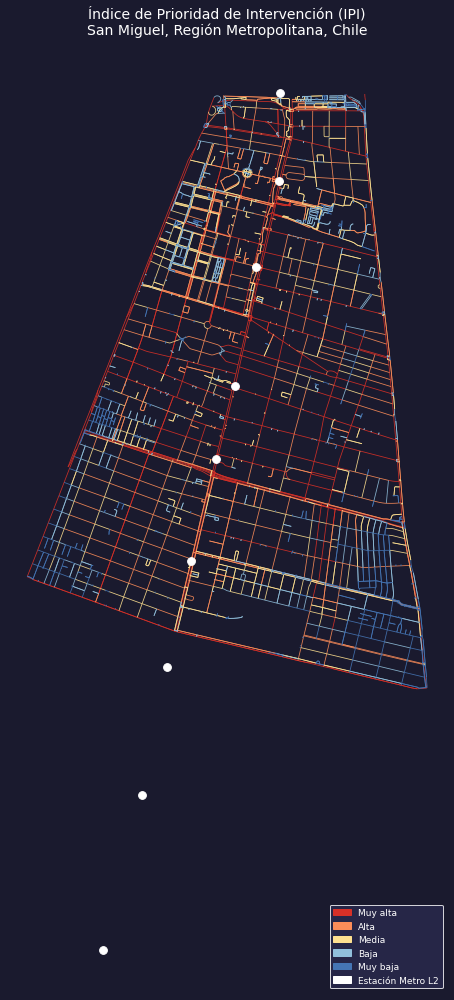

✅ Mapa guardado como 'mapa_ipi_san_miguel.png'


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 7 — Mapa estático IPI (matplotlib)                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

COLOR_MAP = {
    'Muy alta': '#d73027',
    'Alta':     '#fc8d59',
    'Media':    '#fee090',
    'Baja':     '#91bfdb',
    'Muy baja': '#4575b4',
}

NOMBRE_ARCHIVO = PLACE.split(',')[0].lower().replace(' ', '_')

fig, ax = plt.subplots(figsize=(12, 14))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

for prioridad, color in COLOR_MAP.items():
    subset = edges[edges['prioridad'] == prioridad]
    subset.plot(ax=ax, color=color, linewidth=0.8, alpha=0.9)

# Estaciones de Metro
gdf_metro_wgs84 = gdf_metro.to_crs('EPSG:4326')
gdf_metro_wgs84.plot(ax=ax, color='white', marker='o', markersize=60,
                      zorder=5, label='Estación Metro L2')

patches = [mpatches.Patch(color=v, label=k) for k, v in COLOR_MAP.items()]
patches.append(mpatches.Patch(color='white', label='Estación Metro L2'))
ax.legend(handles=patches, loc='lower right', fontsize=9,
          facecolor='#2a2a4e', edgecolor='white', labelcolor='white')

ax.set_title(
    f'Índice de Prioridad de Intervención (IPI)\n{PLACE}',
    color='white', fontsize=14, pad=15
)
ax.set_axis_off()
plt.tight_layout()

fname = f'mapa_ipi_{NOMBRE_ARCHIVO}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f"✅ Mapa guardado como '{fname}'")


---
### 🌐 Celda 8 — Mapa interactivo (Folium / Leaflet.js)

**Objetivo:** Generar un **mapa web interactivo** que permite hacer zoom,  
hacer clic en cada segmento y ver sus atributos (IPI, prioridad, tipo de vía,  
longitud, tipo de intervención y costo estimado).

**Tecnología:** [Folium](https://python-visualization.github.io/folium/) genera  
mapas Leaflet.js como archivos HTML autocontenidos — se pueden abrir en cualquier  
navegador sin necesidad de servidor o conexión a internet.

**Corrección técnica:** Se usa `GeoJson` con `style_function` en lugar de  
iterar arista por arista con `PolyLine`, lo cual es mucho más rápido y  
renderiza la geometría completa (curvas incluidas).

**Lo que verás al ejecutar:** Un mapa interactivo guardado como archivo `.html`.  
Al abrir en el browser puedes hacer clic en cada calle y ver su ficha completa.


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELDA 8 — Mapa interactivo Folium + 11 Cuadrantes Gran Avenida     ║
# ╚══════════════════════════════════════════════════════════════════════╝

import folium
from folium import GeoJson, GeoJsonTooltip
import geopandas as gpd
import numpy as np
from shapely.geometry import box
from shapely.ops import unary_union

FOLIUM_COLORS = {
    'Muy alta': '#d73027', 'Alta': '#fc8d59',
    'Media':    '#fee090', 'Baja': '#91bfdb', 'Muy baja': '#4575b4',
}

# ── 1. Preparar edges_map ─────────────────────────────────────────────
edges_map = edges[['geometry', 'IPI', 'prioridad', 'highway',
                    'length_m', 'name', 'jerarquia']].copy()

def tipo_intervencion(prioridad):
    return {
        'Muy alta': 'Repavimentación + señalización + iluminación',
        'Alta':     'Repavimentación + señalización',
        'Media':    'Señalización + bacheo puntual',
        'Baja':     'Bacheo puntual',
        'Muy baja': 'Mantención preventiva',
    }.get(prioridad, 'Evaluación pendiente')

def costo_segmento(row, ancho_m=ANCHO_PROMEDIO_M):
    area = row['length_m'] * ancho_m
    return {
        'Muy alta': area * COSTOS_UNITARIOS['repavimentacion']
                    + row['length_m'] * COSTOS_UNITARIOS['iluminación'],
        'Alta':     area * COSTOS_UNITARIOS['repavimentacion'],
        'Media':    area * COSTOS_UNITARIOS['señalización'],
        'Baja':     area * COSTOS_UNITARIOS['señalización'] * 0.3,
        'Muy baja': area * COSTOS_UNITARIOS['señalización'] * 0.1,
    }.get(row['prioridad'], 0)

edges_map['intervencion']       = edges_map['prioridad'].apply(tipo_intervencion)
edges_map['costo_estimado_clp'] = edges_map.apply(costo_segmento, axis=1)
edges_map['costo_fmt']          = edges_map['costo_estimado_clp'].apply(lambda x: f"${x:,.0f} CLP")
edges_map['IPI_fmt']            = edges_map['IPI'].apply(lambda x: f"{x:.4f}")
edges_wgs84 = edges_map.to_crs('EPSG:4326')

# ── 2. Polígono comunal en UTM 19S ────────────────────────────────────
gdf_place   = ox.geocode_to_gdf(PLACE)
centroid    = gdf_place.geometry.centroid.iloc[0]
comuna_utm  = gdf_place.to_crs("EPSG:32719")
comuna_poly = comuna_utm.geometry.iloc[0]
minx, miny, maxx, maxy = comuna_poly.bounds

# ── 3. Extraer Gran Avenida José Miguel Carrera ───────────────────────
def es_gran_avenida(val):
    if isinstance(val, list):
        return any("gran" in str(n).lower() and "carrera" in str(n).lower() for n in val)
    return "gran" in str(val).lower() and "carrera" in str(val).lower()

mask_gav    = edges["name"].apply(es_gran_avenida)
gran_av_utm = edges[mask_gav].to_crs("EPSG:32719")

if gran_av_utm.empty:
    mask_gav    = edges["name"].apply(lambda x:
        any("carrera" in str(n).lower() for n in x) if isinstance(x, list)
        else "carrera" in str(x).lower())
    gran_av_utm = edges[mask_gav].to_crs("EPSG:32719")

# Filtrar geometrías inválidas / nulas / vacías
gran_av_utm = gran_av_utm[
    gran_av_utm.geometry.notna() &
    gran_av_utm.geometry.is_valid &
    ~gran_av_utm.geometry.is_empty
].copy()
print(f"✅ Segmentos válidos de Gran Avenida: {len(gran_av_utm)}")

gran_av_union = unary_union(list(gran_av_utm.geometry))

# ── 4. Calcular cortes Y para 11 cuadrantes ───────────────────────────
all_y = []
for g in gran_av_utm.geometry:
    if g and not g.is_empty:
        all_y.extend([c[1] for c in g.coords])

cortes_y      = np.linspace(min(all_y), max(all_y), 12)
cortes_y[0]   = miny
cortes_y[-1]  = maxy
print(f"✅ Cortes Y: Sur {cortes_y[0]:.0f} m → Norte {cortes_y[-1]:.0f} m")

# ── 5. Construir 11 cuadrantes (UTM → WGS84) ─────────────────────────
COLORES_GRUPO = [
    "#e6194b", "#f58231", "#ffe119", "#3cb44b", "#42d4f4",
    "#4363d8", "#911eb4", "#f032e6", "#a9a9a9", "#9A6324", "#469990"
]

cuadrantes_wgs84 = []
for i in range(11):
    rect     = box(minx - 500, cortes_y[i], maxx + 500, cortes_y[i + 1])
    geom_utm = rect.intersection(comuna_poly)
    geom_wgs = (gpd.GeoDataFrame([{"geometry": geom_utm}], crs="EPSG:32719")
                .to_crs("EPSG:4326").geometry.iloc[0])
    cuadrantes_wgs84.append({
        "grupo":    f"Grupo {i + 1}",
        "numero":   i + 1,
        "color":    COLORES_GRUPO[i],
        "geometry": geom_wgs
    })

gdf_cuadrantes = gpd.GeoDataFrame(cuadrantes_wgs84, crs="EPSG:4326")
print(f"✅ {len(gdf_cuadrantes)} cuadrantes generados")

# ── 6. Construir mapa Folium ──────────────────────────────────────────
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=14,
               tiles='CartoDB dark_matter')

# Capa 1 — Cuadrantes (fondo semitransparente + etiqueta centroide)
for _, row in gdf_cuadrantes.iterrows():
    folium.GeoJson(
        row["geometry"].__geo_interface__,
        name=row["grupo"],
        style_function=lambda feat, c=row["color"]: {
            "fillColor":   c,
            "color":       c,
            "weight":      2,
            "fillOpacity": 0.18,
            "dashArray":   "6 4",
        },
        tooltip=folium.Tooltip(
            f"<b style='color:white;font-size:13px'>{row['grupo']}</b>"
            f"<br><span style='color:#ccc;font-size:11px'>Gran Av. J.M. Carrera</span>",
            sticky=True,
        ),
    ).add_to(m)

    cent = row["geometry"].centroid
    folium.Marker(
        location=[cent.y, cent.x],
        icon=folium.DivIcon(
            html=f"""<div style="
                font-family:Arial,sans-serif;font-size:11px;font-weight:bold;
                color:white;background:rgba(0,0,0,0.60);
                border:1.5px solid {row['color']};border-radius:4px;
                padding:2px 7px;white-space:nowrap;
                text-shadow:0 0 4px #000;">
                {row['grupo']}
            </div>""",
            icon_size=(72, 22),
            icon_anchor=(36, 11),
        )
    ).add_to(m)

# Capa 2 — Red vial IPI
def style_fn(feature):
    p = feature['properties'].get('prioridad', 'Muy baja')
    return {'color': FOLIUM_COLORS.get(p, '#999'), 'weight': 3, 'opacity': 0.85}

def highlight_fn(feature):
    return {'color': 'white', 'weight': 5, 'opacity': 1.0}

GeoJson(
    edges_wgs84,
    style_function=style_fn,
    highlight_function=highlight_fn,
    tooltip=GeoJsonTooltip(
        fields=['prioridad', 'IPI_fmt', 'highway', 'length_m', 'intervencion', 'costo_fmt'],
        aliases=['Prioridad:', 'IPI:', 'Tipo vía:', 'Longitud (m):', 'Intervención:', 'Costo estimado:'],
        localize=True, sticky=False,
    )
).add_to(m)

# Capa 3 — Estaciones Metro
for i, (lat, lon) in enumerate(estaciones_metro_wgs84):
    folium.Marker(
        location=[lat, lon],
        popup=f"🚇 {nombres_metro[i]} — Metro L2",
        tooltip=f"Metro: {nombres_metro[i]}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

# ── 7. Leyenda combinada IPI + Cuadrantes ─────────────────────────────
leyenda_grupos = "".join([
    f'<span style="color:{COLORES_GRUPO[i]}">■</span> Grupo {i+1}<br>'
    for i in range(11)
])

legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:rgba(26,26,46,0.93);padding:12px 16px;
            border-radius:8px;border:1px solid #666;color:white;
            font-family:Arial,sans-serif;font-size:11px;
            max-height:90vh;overflow-y:auto;line-height:1.7;">
  <b style="font-size:12px">Prioridad IPI</b><br>
  <span style="color:#d73027">■</span> Muy alta — Repavimentación + iluminación<br>
  <span style="color:#fc8d59">■</span> Alta — Repavimentación<br>
  <span style="color:#fee090">■</span> Media — Señalización + bacheo<br>
  <span style="color:#91bfdb">■</span> Baja — Bacheo puntual<br>
  <span style="color:#4575b4">■</span> Muy baja — Mantención preventiva<br>
  <span style="color:white">●</span> Estación Metro L2<br>
  <hr style="border-color:#444;margin:6px 0">
  <b style="font-size:12px">Grupos de Trabajo Alumnos</b><br>
  {leyenda_grupos}
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── 8. Guardar ────────────────────────────────────────────────────────
NOMBRE_ARCHIVO = PLACE.split(',')[0].lower().replace(' ', '_')
fname_html = f'mapa_ipi_{NOMBRE_ARCHIVO}_interactivo.html'
m.save(fname_html)
print(f"✅ Mapa interactivo guardado como '{fname_html}'")
print(f"   Abre el archivo en tu navegador para explorar la red.")
m

✅ Segmentos válidos de Gran Avenida: 180
✅ Cortes Y: Sur 6289998 m → Norte 6294692 m
✅ 11 cuadrantes generados
✅ Mapa interactivo guardado como 'mapa_ipi_san_miguel_interactivo.html'
   Abre el archivo en tu navegador para explorar la red.


---
### 💰 Celda 9 — Modelo de costos por segmento

**Objetivo:** Estimar el **costo total de intervención** para cada segmento  
según su nivel de prioridad IPI y dimensiones físicas (longitud × ancho).

**Costos unitarios MOP/MINVU 2025-2026** (definidos en Celda 1):
- Repavimentación: 8.500 CLP/m²
- Señalización: 1.200 CLP/m²
- Iluminación: 3.500 CLP/m lineal

**Supuesto clave:** `ANCHO_PROMEDIO_M = 7.0 m` (definido en Celda 1).  
En un proyecto profesional se mide en terreno o con fotointerpretación satelital  
(Google Maps, imágenes Sentinel-2, etc.).

**Lo que verás:** Tabla resumen con costo total por categoría de prioridad,  
porcentaje de cobertura posible con el presupuesto disponible.

> 💡 El tipo de cambio USD (`TIPO_CAMBIO_USD`) también está centralizado  
> en la Celda 1 para facilitar actualizaciones.


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 9 — Modelo de costos                                                ║
# ║  Usa ANCHO_PROMEDIO_M de Celda 1. Actualiza allí para propagar aquí.       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

edges_map['area_m2']           = edges_map['length_m'] * ANCHO_PROMEDIO_M
edges_map['costo_estimado_clp'] = edges_map.apply(costo_segmento, axis=1)

resumen_costos = edges_map.groupby('prioridad').agg(
    n_segmentos       = ('IPI', 'count'),
    longitud_total_km = ('length_m', lambda x: x.sum() / 1000),
    area_total_m2     = ('area_m2', 'sum'),
    costo_total_clp   = ('costo_estimado_clp', 'sum'),
).reset_index()

resumen_costos['costo_total_mclp']    = resumen_costos['costo_total_clp'] / 1e6
resumen_costos['costo_prom_usd_m']    = (
    resumen_costos['costo_total_clp'] / resumen_costos['n_segmentos']
    / TIPO_CAMBIO_USD                # referencia: Celda 1
)

orden = ['Muy alta', 'Alta', 'Media', 'Baja', 'Muy baja']
resumen_costos['prioridad'] = pd.Categorical(resumen_costos['prioridad'],
                                              categories=orden, ordered=True)
resumen_costos = resumen_costos.sort_values('prioridad').reset_index(drop=True)

costo_total = resumen_costos['costo_total_clp'].sum()

print("=== MODELO DE COSTOS POR CATEGORÍA DE PRIORIDAD ===\n")
print(resumen_costos[['prioridad','n_segmentos','longitud_total_km','costo_total_mclp']]
      .to_string(index=False, float_format=lambda x: f"{x:,.1f}"))
print(f"\nCosto total estimado      : ${costo_total/1e9:.2f} mil millones CLP")
print(f"Presupuesto disponible    : ${PRESUPUESTO_CLP/1e9:.2f} mil millones CLP")
print(f"Cobertura con presupuesto : {PRESUPUESTO_CLP/costo_total*100:.1f}%")


=== MODELO DE COSTOS POR CATEGORÍA DE PRIORIDAD ===

prioridad  n_segmentos  longitud_total_km  costo_total_mclp
 Muy alta         1360               81.8           5,151.6
     Alta         1359               96.1           5,719.1
    Media         1360               69.4             582.8
     Baja         1358               48.4             122.0
 Muy baja         1361               35.8              30.0

Costo total estimado      : $11.61 mil millones CLP
Presupuesto disponible    : $2.50 mil millones CLP
Cobertura con presupuesto : 21.5%


---
### 🗄️ Celda 10 — Exportación GIS

**Objetivo:** Exportar los resultados a **formatos GIS estándar** para uso  
en QGIS, ArcGIS o sistemas SIG municipales.

**Formatos generados:**
1. **GeoPackage (.gpkg):** Formato recomendado (un único archivo, sin límite de 10 caracteres en nombres de columnas).
2. **CSV:** Para análisis en Excel o Python externo (sin geometría).
3. **Shapefile (.shp):** Compatibilidad con sistemas legados (trunca nombres a 10 chars).

**¿Cuándo usar cada uno?**
- Presenta el GPKG al municipio o empresa consultora → son los que usan QGIS.
- Usa el CSV para tablas en informes.
- El Shapefile solo si el receptor usa software muy antiguo.


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 10 — Exportación GIS (GeoPackage, CSV, Shapefile)                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os

COLS_EXPORT = ['u', 'v', 'key', 'highway', 'name', 'length_m',
               'jerarquia', 'betweenness', 'IPI', 'prioridad',
               'intervencion', 'costo_estimado_clp', 'geometry']

cols_ok   = [c for c in COLS_EXPORT if c in edges_map.columns]
edges_shp = edges_map[cols_ok].copy()
edges_shp['prioridad']    = edges_shp['prioridad'].astype(str)
edges_shp['intervencion'] = edges_shp['intervencion'].astype(str)
edges_shp['highway']      = edges_shp['highway'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x)
)
edges_shp_wgs84 = edges_shp.to_crs(epsg=4326)

base = NOMBRE_ARCHIVO

# 1. GeoPackage
try:
    edges_shp_wgs84.to_file(f'ipi_{base}.gpkg', driver='GPKG', layer='red_vial_ipi')
    print(f"✅ GeoPackage: 'ipi_{base}.gpkg'")
except Exception as e:
    print(f"⚠️  GeoPackage: {e}  → pip install fiona --upgrade")

# 2. CSV
csv_path = f'ipi_{base}_tabla.csv'
edges_shp_wgs84.drop(columns='geometry').to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"✅ CSV:         '{csv_path}'")

# 3. Shapefile
try:
    edges_shp_wgs84.to_file(f'ipi_{base}.shp')
    print(f"✅ Shapefile:  'ipi_{base}.shp'")
except Exception as e:
    print(f"⚠️  Shapefile: {e}")

print("\nArchivos generados:")
for f in [f'ipi_{base}.gpkg', csv_path, f'ipi_{base}.shp']:
    if os.path.exists(f):
        print(f"  {f:45s} ({os.path.getsize(f)/1024:.0f} KB)")


⚠️  GeoPackage: Invalid input to create CRS: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]  → pip install fiona --upgrade
✅ CSV:         'ipi_san_miguel_tabla.csv'
⚠️  Shapefile: Invalid input to create CRS: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensembl

---
### 📋 Celda 11 — Resultados técnicos: Top-20 segmentos prioritarios

**Objetivo:** Mostrar los **20 segmentos con mayor IPI** junto a sus atributos  
técnicos y económicos, y generar un resumen general de la red.

**Interpretación:** Los segmentos del top-20 son los candidatos inmediatos  
para la primera fase de intervención, dado el nivel de urgencia y el impacto  
agregado sobre la red (betweenness alto + jerarquía alta).

**Para tu informe:** Esta tabla es el insumo directo para la ficha de proyecto  
SNI y para el capítulo de priorización del informe final.


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 11 — Top-20 segmentos prioritarios y resumen general                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

top20 = (edges_map
         .nlargest(20, 'IPI')
         [['name', 'highway', 'jerarquia', 'IPI', 'prioridad',
           'length_m', 'costo_estimado_clp']]
         .copy())

top20['highway']    = top20['highway'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x)
)
top20['costo_mclp'] = top20['costo_estimado_clp'] / 1e6
top20['IPI']        = top20['IPI'].round(4)

print("=== TOP-20 SEGMENTOS POR ÍNDICE DE PRIORIDAD DE INTERVENCIÓN ===")
print("  Nota: 'name' puede ser NaN en segmentos sin nombre en OSM.\n")
print(top20[['name', 'highway', 'jerarquia', 'IPI', 'prioridad',
             'length_m', 'costo_mclp']].to_string(index=False))

print(f"\n=== RESUMEN GENERAL DE LA RED VIAL ===")
print(f"  Total segmentos analizados  : {len(edges_map):,}")
print(f"  Longitud total red vial     : {edges_map['length_m'].sum()/1000:.1f} km")
print(f"  Red de prioridad 'Muy alta' : {edges_map[edges_map['prioridad']=='Muy alta']['length_m'].sum()/1000:.1f} km")
print(f"  Costo total estimado        : ${edges_map['costo_estimado_clp'].sum()/1e9:.2f} mil millones CLP")
print(f"  Costo solo prioridad alta+  : ${edges_map[edges_map['prioridad'].isin(['Muy alta','Alta'])]['costo_estimado_clp'].sum()/1e6:.0f} M CLP")


=== TOP-20 SEGMENTOS POR ÍNDICE DE PRIORIDAD DE INTERVENCIÓN ===
  Nota: 'name' puede ser NaN en segmentos sin nombre en OSM.

                            name highway  jerarquia    IPI prioridad  length_m  costo_mclp
Gran Avenida José Miguel Carrera primary          4 0.9306  Muy alta   175.295   11.043585
Gran Avenida José Miguel Carrera primary          4 0.9175  Muy alta   134.532    8.475516
Gran Avenida José Miguel Carrera primary          4 0.9128  Muy alta   125.152    7.884576
Gran Avenida José Miguel Carrera primary          4 0.9122  Muy alta   122.949    7.745787
Gran Avenida José Miguel Carrera primary          4 0.9107  Muy alta   104.756    6.599628
Gran Avenida José Miguel Carrera primary          4 0.9100  Muy alta   164.152   10.341576
Gran Avenida José Miguel Carrera primary          4 0.9068  Muy alta   114.493    7.213059
Gran Avenida José Miguel Carrera primary          4 0.9059  Muy alta    87.476    5.510988
Gran Avenida José Miguel Carrera primary          4 0.

---
## ¿Por qué este notebook va más allá de la priorización técnica?

Un error frecuente en los estudios de infraestructura vial es detenerse
en el diagnóstico: identificar qué calles están en peor estado o tienen
mayor demanda, y entregar ese ranking como producto final. El Bloque 1
(IPI) hace exactamente eso — y es necesario, pero **insuficiente** para
tomar decisiones de inversión pública.

Un ingeniero a cargo de un proyecto FNDR o sectorial enfrenta, después
del diagnóstico, dos preguntas adicionales igualmente técnicas:

---

### ¿Por qué existe el Bloque 2? — La pregunta operacional

> *"Tengo 463 segmentos de alta prioridad. ¿En qué orden los intervengo?  
> ¿Cuántas cuadrillas necesito? ¿Cuánto tiempo toma el programa completo?"*

El **Bloque 2** modela estas restricciones usando herramientas de **Gestión de Operaciones**:

| Celda | Herramienta | Pregunta que responde |
|-------|-------------|----------------------|
| A0 | Análisis de sensibilidad IPI | ¿Cambia el ranking si cambio los pesos? |
| A1 | Scheduling Round-Robin | ¿En qué secuencia ejecutar? ¿Cuánto dura el programa? |
| A2 | Diagrama de Gantt | ¿Cómo visualizar el cronograma? |
| A3 | Clustering K-Means | ¿Cómo agrupar obras geográficamente? |

---

### ¿Por qué existe el Bloque 3? — La pregunta financiera

> *"¿Vale la pena invertir estos recursos aquí? ¿Qué proyectos ejecutar  
> si el presupuesto no alcanza para todo?"*

En Chile, **toda inversión pública superior a 30 millones de pesos requiere evaluación  
social ex ante** según la metodología del SNI (MIDEPLAN). Sin esa evaluación, el  
proyecto no puede postular a financiamiento FNDR, sectorial o municipal.

| Celda | Herramienta | Pregunta que responde |
|-------|-------------|----------------------|
| B1 | VAN / TIR / Ratio B/C | ¿Es rentable socialmente cada intervención? |
| B2 | Análisis de sensibilidad | ¿Qué tan sensible es el VAN a cambios en supuestos? |
| B3 | Optimización Knapsack | ¿Qué proyectos maximizan el impacto con el presupuesto? |


---
# ⚙️ Bloque 2 — Programación de Operaciones

Tenemos el ranking IPI. Ahora necesitamos convertirlo en un **programa ejecutable**:  
secuencia de obras, asignación de recursos (cuadrillas) y cronograma temporal.


---
### 🔬 Celda A0 — Análisis de sensibilidad de pesos IPI

**Objetivo:** Evaluar la **robustez del ranking IPI** ante variaciones de ±20%  
en cada uno de los cinco pesos del modelo.

**Método:** Para cada perturbación se recalcula el IPI y se mide el % de  
segmentos que cambian de categoría de prioridad respecto al modelo base.

**Criterio de robustez:**
- **< 20% cambian:** Modelo robusto — pequeñas variaciones no alteran el ranking significativamente.
- **20–30% cambian:** Modelo moderadamente sensible — revisar los pesos con AHP formal.
- **> 30% cambian:** Modelo frágil — los pesos deben calibrarse con datos y juicio de expertos.

**Relevancia para tu proyecto:** Si el modelo no es robusto ante un factor,  
significa que ese factor es el que más influye en el ranking y debe estimarse  
con mayor precisión (idealmente con datos de campo, no proxies).


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA A0 — Análisis de sensibilidad de pesos IPI                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
"""
Para cada peso del IPI, lo perturba ±20% (renormalizando el resto para que sumen 1)
y mide cuántos segmentos cambian de categoría de prioridad.

Si < 20% de segmentos cambian → modelo robusto ante esa perturbación.
"""

variables_ipi = {
    'betweenness': edges['betweenness_norm'],
    'accidentes':  edges['acc_norm'],
    'densidad':    edges['dens_pob_proxy'],
    'jerarquia':   edges['jerarquia_norm'],
    'metro':       edges['metro_norm'],
}

resultados_sens = []
for var_perturb in PESOS.keys():
    for delta in [-0.20, +0.20]:
        pesos_mod   = PESOS.copy()
        nuevo_peso  = pesos_mod[var_perturb] * (1 + delta)
        if nuevo_peso < 0:
            continue
        pesos_mod[var_perturb] = nuevo_peso
        total     = sum(pesos_mod.values())
        pesos_mod = {k: v / total for k, v in pesos_mod.items()}

        ipi_mod       = sum(pesos_mod[k] * variables_ipi[k] for k in pesos_mod)
        prioridad_mod = pd.qcut(ipi_mod, q=5,
                                labels=['Muy baja','Baja','Media','Alta','Muy alta'],
                                duplicates='drop').astype(str)
        pct_cambio = (prioridad_mod != edges['prioridad']).mean() * 100

        resultados_sens.append({
            'Variable':     var_perturb,
            'Perturbación': f"{'+' if delta>0 else ''}{delta*100:.0f}%",
            'Peso orig.':   f"{PESOS[var_perturb]:.2f}",
            'Peso modif.':  f"{nuevo_peso:.2f}",
            '% cambian':    f"{pct_cambio:.1f}%",
            'Robustez':     '✅ Robusto' if pct_cambio < 20 else ('⚠️ Revisar' if pct_cambio < 30 else '❌ Frágil'),
        })

df_sens = pd.DataFrame(resultados_sens)
print("=== ANÁLISIS DE SENSIBILIDAD DE PESOS IPI ===\n")
print(df_sens.to_string(index=False))
print(f"\nCriterio: <20% → robusto | 20-30% → revisar | >30% → frágil")


=== ANÁLISIS DE SENSIBILIDAD DE PESOS IPI ===

   Variable Perturbación Peso orig. Peso modif. % cambian  Robustez
betweenness         -20%       0.35        0.28      7.0% ✅ Robusto
betweenness         +20%       0.35        0.42      5.4% ✅ Robusto
 accidentes         -20%       0.25        0.20      1.4% ✅ Robusto
 accidentes         +20%       0.25        0.30      1.3% ✅ Robusto
   densidad         -20%       0.20        0.16      4.9% ✅ Robusto
   densidad         +20%       0.20        0.24      5.4% ✅ Robusto
  jerarquia         -20%       0.10        0.08      0.3% ✅ Robusto
  jerarquia         +20%       0.10        0.12      0.4% ✅ Robusto
      metro         -20%       0.10        0.08      6.5% ✅ Robusto
      metro         +20%       0.10        0.12      4.7% ✅ Robusto

Criterio: <20% → robusto | 20-30% → revisar | >30% → frágil


---
### 📅 Celda A1 — Programación de obras (Scheduling)

**Objetivo:** Asignar las obras de mayor prioridad (Muy alta + Alta)  
a las cuadrillas disponibles y generar un **cronograma de ejecución**.

**Algoritmo: Round-Robin ponderado por IPI**  
Asigna segmentos ordenados por IPI descendente en forma cíclica entre cuadrillas.  
Es O(n), equitativo en carga y fácil de auditar.

**Supuestos del modelo:**
- Rendimiento: 50 m²/día por cuadrilla (repavimentación).
- Meses bloqueados: enero y febrero (veda estival municipal).
- El calendario usa **días laborales efectivos** (excluyendo los meses bloqueados).

**Corrección aplicada:** La función `dia_laboral_a_calendario()` convierte  
correctamente días laborales acumulados a mes y día calendario, saltando  
los meses bloqueados antes de asignar el inicio de cada obra.  
(Versión anterior acumulaba días linealmente sin excluir los meses de pausa.)

> 💡 **Concepto de Gestión de Operaciones:** El *makespan* es el tiempo total  
> hasta completar todas las obras del programa. Minimizarlo es el objetivo  
> de los algoritmos de scheduling.


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA A1 — Programación de obras (Scheduling Round-Robin)                 ║
# ║  CORRECCIÓN: dia_laboral_a_calendario() excluye correctamente los meses     ║
# ║  bloqueados al acumular días efectivos de trabajo.                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

RENDIMIENTO_M2_DIA = 50      # m²/día por cuadrilla (repavimentación)
MESES_BLOQUEADOS   = {1, 2}  # enero y febrero (veda estival)
MES_INICIO         = 3       # inicio de obras: marzo

def dia_laboral_a_calendario(dia_efectivo,
                              mes_inicio=MES_INICIO,
                              meses_bloqueados=MESES_BLOQUEADOS,
                              dias_lab_mes=DIAS_LABORALES_MES):
    """
    Convierte días laborales efectivos (excluyendo meses bloqueados) al mes
    y día calendario correspondientes.

    Ejemplo (MES_INICIO=3, MESES_BLOQUEADOS={1,2}):
      dia_efectivo=1  → (marzo, día 1)
      dia_efectivo=22 → (marzo, día 22) — fin de marzo
      dia_efectivo=23 → (abril,  día 1) — salta enero/febrero aunque caigan
      dia_efectivo=44 → (abril,  día 22)

    CORRECCIÓN vs versión anterior: el acumulador de días ya no avanza
    durante los meses bloqueados, eliminando el error de makespan.
    """
    mes       = mes_inicio
    restantes = dia_efectivo
    for _ in range(12 * 6):       # límite: 6 años calendario
        if mes not in meses_bloqueados:
            if restantes <= dias_lab_mes:
                return mes, restantes
            restantes -= dias_lab_mes
        mes = (mes % 12) + 1
    return mes, restantes  # fallback (no debería alcanzarse)

# Seleccionar obras prioritarias
obras = (edges_map[edges_map['prioridad'].isin(['Muy alta', 'Alta'])]
         .sort_values('IPI', ascending=False)
         .copy()
         .reset_index(drop=True))

obras['area_m2']        = obras['length_m'] * ANCHO_PROMEDIO_M
obras['dias_ejecucion'] = np.ceil(obras['area_m2'] / RENDIMIENTO_M2_DIA).astype(int).clip(lower=1)
obras['cuadrilla']      = [f"C{(i % CUADRILLAS_TOTAL) + 1}" for i in range(len(obras))]

# Contador de días laborales efectivos por cuadrilla
contadores_ef = {f"C{i+1}": 0 for i in range(CUADRILLAS_TOTAL)}

obras['mes_inicio_obra']      = 0
obras['dia_inicio_obra']      = 0
obras['dia_efectivo_inicio']  = 0

for idx, row in obras.iterrows():
    c            = row['cuadrilla']
    dia_ef_ini   = contadores_ef[c] + 1
    mes_r, dia_r = dia_laboral_a_calendario(dia_ef_ini)
    obras.at[idx, 'mes_inicio_obra']     = mes_r
    obras.at[idx, 'dia_inicio_obra']     = dia_r
    obras.at[idx, 'dia_efectivo_inicio'] = dia_ef_ini
    contadores_ef[c] += row['dias_ejecucion']

# Resumen por cuadrilla
resumen_c = obras.groupby('cuadrilla').agg(
    n_obras      = ('IPI', 'count'),
    longitud_km  = ('length_m', lambda x: x.sum() / 1000),
    dias_ef      = ('dias_ejecucion', 'sum'),
    costo_mclp   = ('costo_estimado_clp', lambda x: x.sum() / 1e6),
).reset_index()
resumen_c['meses_laborales'] = (resumen_c['dias_ef'] / DIAS_LABORALES_MES).round(1)

makespan_ef = max(contadores_ef.values())
mes_fin, dia_fin = dia_laboral_a_calendario(makespan_ef)

NOMBRE_MESES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
                7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

print("=== PROGRAMACIÓN DE OBRAS (SCHEDULING ROUND-ROBIN) ===\n")
print(f"Total obras programadas : {len(obras)} segmentos")
print(f"Cuadrillas              : {CUADRILLAS_TOTAL}")
print(f"Meses bloqueados        : {sorted(MESES_BLOQUEADOS)} (enero y febrero)\n")
print(resumen_c.to_string(index=False))
print(f"\nMakespan (días laborales efectivos) : {makespan_ef}")
print(f"Fin estimado del programa           : {NOMBRE_MESES[mes_fin]}, día {dia_fin}")


=== PROGRAMACIÓN DE OBRAS (SCHEDULING ROUND-ROBIN) ===

Total obras programadas : 2719 segmentos
Cuadrillas              : 4
Meses bloqueados        : [1, 2] (enero y febrero)

cuadrilla  n_obras  longitud_km  dias_ef  costo_mclp  meses_laborales
       C1      680    42.218777     6225 2577.036228            283.0
       C2      680    42.928331     6335 2623.071721            288.0
       C3      680    46.774602     6890 2860.545611            313.2
       C4      679    45.969675     6761 2810.084620            307.3

Makespan (días laborales efectivos) : 6890
Fin estimado del programa           : Mar, día 5570


---
### 📊 Celda A2 — Diagrama de Gantt

**Objetivo:** Visualizar el **cronograma de obras** como un diagrama de Gantt,  
donde el eje X muestra días laborales acumulados (efectivos, excluyendo meses bloqueados)  
y el eje Y muestra cada segmento ordenado por IPI descendente.

**Lectura del gráfico:**
- Cada barra = un segmento de calle a intervenir.
- Color = cuadrilla asignada.
- Longitud de la barra = duración en días laborables.
- Líneas verticales punteadas = límites de mes (cada 22 días laborables).

**Nota:** Se muestran solo los primeros 50 segmentos para legibilidad.


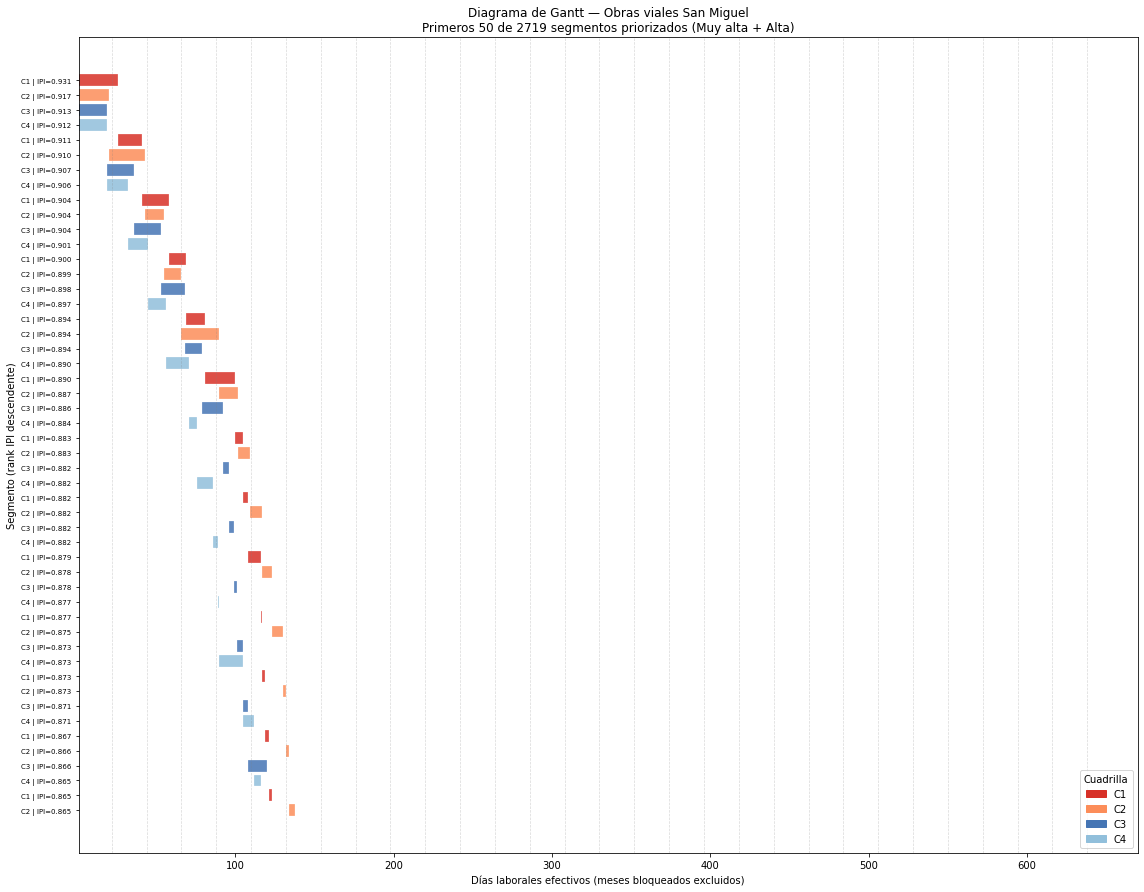

✅ Gantt guardado como 'gantt_obras_san_miguel.png'


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA A2 — Diagrama de Gantt                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

N_GANTT  = min(50, len(obras))
obras_g  = obras.head(N_GANTT).copy()

GANTT_COLORS = {
    'C1': '#d73027', 'C2': '#fc8d59',
    'C3': '#4575b4', 'C4': '#91bfdb',
}

fig, ax = plt.subplots(figsize=(16, max(8, N_GANTT * 0.25)))

for i, (_, row) in enumerate(obras_g.iterrows()):
    c = row['cuadrilla']
    ax.barh(i,
            width=row['dias_ejecucion'],
            left=row['dia_efectivo_inicio'],
            color=GANTT_COLORS.get(c, '#888'),
            alpha=0.85, edgecolor='white', linewidth=0.3)

ax.set_yticks(range(N_GANTT))
ax.set_yticklabels(
    [f"{r['cuadrilla']} | IPI={r['IPI']:.3f}" for _, r in obras_g.iterrows()],
    fontsize=7
)
ax.set_xlabel("Días laborales efectivos (meses bloqueados excluidos)")
ax.set_ylabel("Segmento (rank IPI descendente)")
ax.set_title(
    f"Diagrama de Gantt — Obras viales {PLACE.split(',')[0]}\n"
    f"Primeros {N_GANTT} de {len(obras)} segmentos priorizados (Muy alta + Alta)",
    fontsize=12
)

patches = [mpatches.Patch(color=v, label=k) for k, v in GANTT_COLORS.items()
           if k in obras['cuadrilla'].unique()]
ax.legend(handles=patches, title='Cuadrilla', loc='lower right')

for mes_n in range(1, 30):
    ax.axvline(x=mes_n * DIAS_LABORALES_MES, color='gray',
               linestyle='--', alpha=0.3, linewidth=0.7)

ax.invert_yaxis()
plt.tight_layout()

fname_gantt = f'gantt_obras_{NOMBRE_ARCHIVO}.png'
plt.savefig(fname_gantt, dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ Gantt guardado como '{fname_gantt}'")


---
### 🗺️ Celda A3 — Clustering espacial de cuadrillas (K-Means)

**Objetivo:** Agrupar los segmentos prioritarios en **K zonas geográficas**  
usando K-Means sobre las coordenadas de los centroides en UTM 19S.  
El objetivo es **minimizar tiempos de desplazamiento** entre obras  
asignadas a la misma cuadrilla.

**Algoritmo K-Means:**
- Minimiza la **inercia** (suma de distancias² entre cada punto y el centroide de su cluster).
- `init='k-means++'`: inicialización inteligente que mejora convergencia.
- `n_init=10`: repite 10 veces con distintas semillas, selecciona el mejor resultado.
- **Complejidad:** O(n × K × iteraciones).

**¿Por qué normalizar coordenadas?** `MinMaxScaler` evita que diferencias de  
escala entre X e Y (debidas a la proyección UTM) sesguen el clustering.

**Comparación de enfoques:**
- **Panel izquierdo:** Clustering K-Means (agrupa por proximidad geográfica).
- **Panel derecho:** Round-Robin (ignora geografía, asigna cíclicamente).

El K-Means produce zonas geográficamente compactas → menor tiempo de traslado.


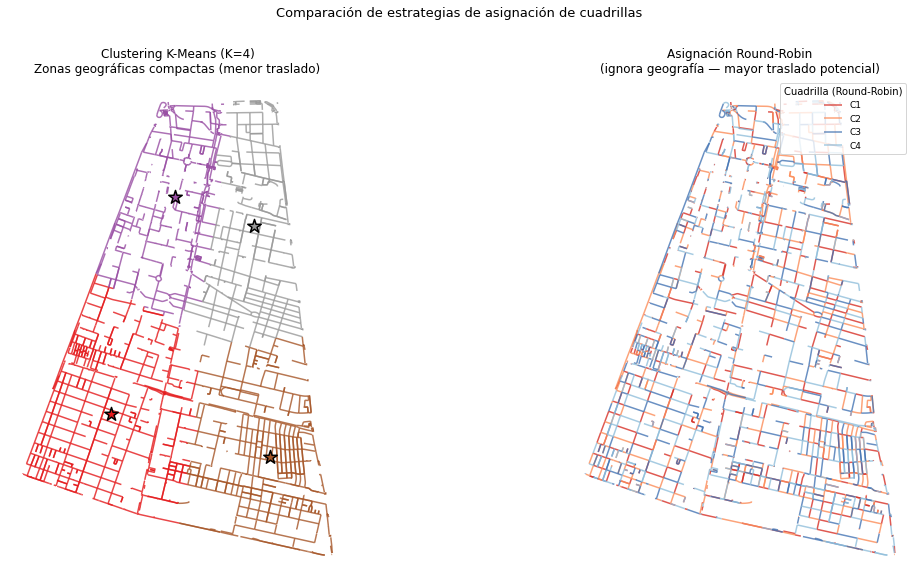

✅ Gráfico de clustering guardado

Resumen por zona K-Means:
        n_obras  IPI_medio  longitud_km
zona                                   
Zona 1      824      0.330       53.496
Zona 2      720      0.365       48.712
Zona 3      701      0.348       44.851
Zona 4      474      0.407       30.832


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA A3 — Clustering espacial de cuadrillas (K-Means)                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

obras_utm = obras.copy()
obras_utm['centroid_x'] = edges_utm.loc[obras.index, 'geometry'].centroid.x.values
obras_utm['centroid_y'] = edges_utm.loc[obras.index, 'geometry'].centroid.y.values

scaler      = MinMaxScaler()
coords_norm = scaler.fit_transform(
    obras_utm[['centroid_x', 'centroid_y']].fillna(0)
)

kmeans = KMeans(n_clusters=CUADRILLAS_TOTAL, init='k-means++',
                n_init=10, random_state=42)
obras_utm['cluster'] = kmeans.fit_predict(coords_norm)
obras_utm['zona']    = obras_utm['cluster'].apply(lambda x: f"Zona {x+1}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Panel izquierdo: K-Means
ax1   = axes[0]
cmap_k = cm.get_cmap('Set1', CUADRILLAS_TOTAL)
for k in range(CUADRILLAS_TOTAL):
    subset = obras_utm[obras_utm['cluster'] == k]
    edges_utm.loc[subset.index].plot(ax=ax1, color=cmap_k(k), linewidth=1.5, alpha=0.8)
    cx, cy   = kmeans.cluster_centers_[k]
    cx_r, cy_r = scaler.inverse_transform([[cx, cy]])[0]
    ax1.scatter(cx_r, cy_r, s=200, c=[cmap_k(k)], marker='*',
                edgecolors='black', zorder=5, linewidths=1.5)
ax1.set_title(f'Clustering K-Means (K={CUADRILLAS_TOTAL})\nZonas geográficas compactas (menor traslado)')
ax1.set_axis_off()

# Panel derecho: Round-Robin
ax2    = axes[1]
cmap_rr = {'C1': '#d73027', 'C2': '#fc8d59', 'C3': '#4575b4', 'C4': '#91bfdb'}
for c, color in cmap_rr.items():
    if c in obras['cuadrilla'].unique():
        edges_utm.loc[obras[obras['cuadrilla'] == c].index].plot(
            ax=ax2, color=color, linewidth=1.5, alpha=0.8, label=c
        )
ax2.legend(title='Cuadrilla (Round-Robin)', fontsize=9)
ax2.set_title('Asignación Round-Robin\n(ignora geografía — mayor traslado potencial)')
ax2.set_axis_off()

plt.suptitle('Comparación de estrategias de asignación de cuadrillas', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'clustering_cuadrillas_{NOMBRE_ARCHIVO}.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Gráfico de clustering guardado")

print("\nResumen por zona K-Means:")
print(obras_utm.groupby('zona').agg(
    n_obras     = ('IPI','count'),
    IPI_medio   = ('IPI','mean'),
    longitud_km = ('length_m', lambda x: x.sum()/1000)
).round(3).to_string())


---
# 💰 Bloque 3 — Evaluación Económica y Optimización Financiera

En Chile, **toda inversión pública superior a 30 millones de pesos requiere evaluación  
social ex ante** según la metodología del Sistema Nacional de Inversiones (SNI) del  
Ministerio de Desarrollo Social y Familia (MIDEPLAN). Sin esa evaluación, el proyecto  
no puede postular a financiamiento FNDR, sectorial o municipal.

Los indicadores que MIDEPLAN exige son precisamente los que calcula este bloque:  
**VAN social, TIR social y Ratio Beneficio/Costo**, a la tasa social del 6%.


---
### 📈 Celda B1 — Evaluación económica social: VAN, TIR, Ratio B/C

**Objetivo:** Calcular los indicadores de rentabilidad social de cada categoría  
de intervención usando la metodología MIDEPLAN (SNI).

**Indicadores:**
- **VAN (Valor Actual Neto):** Beneficios actualizados menos costos actualizados.  
  Si VAN > 0, el proyecto crea valor social.
- **TIR (Tasa Interna de Retorno):** Tasa que hace VAN = 0.  
  Si TIR > 6% (tasa social), el proyecto es eficiente.
- **Ratio B/C:** Beneficios actualizados / Costos actualizados.  
  Si B/C > 1, por cada peso invertido se recupera más de un peso en beneficios.

**Beneficios sociales considerados:**
1. Ahorro en tiempo de viaje (VTTS × reducción de tiempo × usuarios/día × 365 días).
2. Reducción de accidentes (costo social por accidente × tasa de reducción).
3. Ahorro en costos de operación vehicular (COV) — 15% adicional del beneficio de tiempo.

**Horizonte:** 20 años (estándar MIDEPLAN para infraestructura vial).

> 💡 **Todos los parámetros monetarios** (UF_A_CLP, TASA_SOCIAL) se toman de la  
> Celda 1 — cámbia allí y esta celda recalcula automáticamente.


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA B1 — Evaluación económica social: VAN, TIR, Ratio B/C              ║
# ║  Metodología MIDEPLAN (SNI). Usa TASA_SOCIAL y UF_A_CLP de Celda 1.       ║
# ║  CORRECCIÓN: no usa np.npv/np.irr (depreciados). Cálculo manual limpio.    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

HORIZONTE_ANOS  = 20           # años (estándar MIDEPLAN, infraestructura vial)
COSTO_ACC_CLP   = 50_000_000   # Costo social promedio por accidente (MIDEPLAN)
REDUCCION_ACC   = 0.25         # Reducción esperada de accidentes: 25%
USUARIOS_DIA_KM = 5_000        # Usuarios promedio por km de vía (EOD SECTRA)
AHORRO_MIN_KM   = 1.2          # Minutos ahorrados por km intervenido

def evaluar_proyecto(costo_inversion, longitud_km, prioridad, tasa=None):
    """
    Calcula VAN, TIR y B/C para un proyecto vial usando metodología MIDEPLAN.

    Parámetros:
        costo_inversion : costo total del proyecto en CLP
        longitud_km     : longitud del tramo en km
        prioridad       : nivel IPI ('Muy alta', 'Alta', etc.)
        tasa            : tasa social de descuento (default = TASA_SOCIAL de Celda 1)

    Retorna dict con VAN, TIR, ratio_bc, beneficio_anual, viable.

    Beneficios anuales:
      1. Tiempo de viaje : usuarios/día × ahorro_horas/km × VTTS(UF/h) × UF_CLP × 365
      2. Accidentes      : acc/km × longitud × reducción × factor_prioridad × costo_acc
      3. COV             : 15% adicional del beneficio de tiempo

    VAN y TIR calculados manualmente (sin np.npv/np.irr que fueron removidos de NumPy).
    """
    if tasa is None:
        tasa = TASA_SOCIAL  # de Celda 1

    # Beneficio 1: ahorro en tiempo de viaje
    usuarios_dia   = USUARIOS_DIA_KM * longitud_km
    ahorro_horas   = AHORRO_MIN_KM / 60 * longitud_km
    ben_tiempo     = usuarios_dia * ahorro_horas * VALOR_TIEMPO_UF_H * UF_A_CLP * 365

    # Beneficio 2: reducción de accidentes
    factor_acc = {'Muy alta': 1.0, 'Alta': 0.75, 'Media': 0.5,
                  'Baja': 0.25, 'Muy baja': 0.10}.get(prioridad, 0.5)
    km_red_total   = edges_map['length_m'].sum() / 1000
    acc_por_km     = data_comunal['accidentes_2024'] / km_red_total
    ben_accidentes = acc_por_km * longitud_km * REDUCCION_ACC * factor_acc * COSTO_ACC_CLP

    # Beneficio 3: ahorro en costos de operación vehicular (COV)
    ben_cov        = ben_tiempo * 0.15

    beneficio_anual = ben_tiempo + ben_accidentes + ben_cov

    # Flujo de caja: [-inversión, B_anual × T años]
    flujos = [-costo_inversion] + [beneficio_anual] * HORIZONTE_ANOS

    # VAN (cálculo manual, compatible con cualquier versión de NumPy)
    van = sum(f / (1 + tasa) ** t for t, f in enumerate(flujos))

    # TIR (bisección numérica)
    def van_en_tasa(r):
        return sum(f / (1 + r) ** t for t, f in enumerate(flujos))
    lo, hi = 0.001, 5.0
    for _ in range(100):
        mid = (lo + hi) / 2
        (lo if van_en_tasa(mid) > 0 else None)
        if van_en_tasa(mid) > 0:
            lo = mid
        else:
            hi = mid
    tir = (lo + hi) / 2

    # Ratio B/C
    ben_act  = sum(beneficio_anual / (1 + tasa) ** t for t in range(1, HORIZONTE_ANOS + 1))
    ratio_bc = ben_act / costo_inversion if costo_inversion > 0 else 0

    return {
        'VAN': van, 'TIR': tir, 'ratio_bc': ratio_bc,
        'beneficio_anual': beneficio_anual,
        'viable': van > 0 and ratio_bc > 1,
    }

# ── Evaluar por categoría de prioridad ───────────────────────────────────────
print("=== EVALUACIÓN ECONÓMICA SOCIAL — VAN / TIR / B/C ===")
print(f"Tasa social de descuento : {TASA_SOCIAL*100:.1f}%  (MIDEPLAN)")
print(f"Horizonte de evaluación  : {HORIZONTE_ANOS} años")
print(f"UF → CLP                 : ${UF_A_CLP:,}\n")

resultados_eval = []
for _, row in resumen_costos.iterrows():
    r = evaluar_proyecto(
        costo_inversion=row['costo_total_clp'],
        longitud_km=row['longitud_total_km'],
        prioridad=str(row['prioridad']),
    )
    r['prioridad'] = str(row['prioridad'])
    r['costo_mclp'] = row['costo_total_mclp']
    resultados_eval.append(r)

df_eval = pd.DataFrame(resultados_eval)
df_eval['VAN_mclp'] = df_eval['VAN'] / 1e6
df_eval['TIR_pct']  = df_eval['TIR'] * 100
df_eval['Viable']   = df_eval['viable'].map({True: '✅ Sí', False: '❌ No'})

print(df_eval[['prioridad','costo_mclp','VAN_mclp','TIR_pct','ratio_bc','Viable']]
      .to_string(index=False, float_format=lambda x: f"{x:.2f}"))


=== EVALUACIÓN ECONÓMICA SOCIAL — VAN / TIR / B/C ===
Tasa social de descuento : 6.0%  (MIDEPLAN)
Horizonte de evaluación  : 20 años
UF → CLP                 : $40,000

prioridad  costo_mclp  VAN_mclp  TIR_pct  ratio_bc Viable
 Muy alta     5151.61 682741.53   500.00    133.53   ✅ Sí
     Alta     5719.12 922730.28   500.00    162.34   ✅ Sí
    Media      582.76 481549.66   500.00    827.32   ✅ Sí
     Baja      121.98 232019.98   500.00   1903.05   ✅ Sí
 Muy baja       30.04 125005.97   500.00   4162.93   ✅ Sí


---
### 📉 Celda B2 — Análisis de sensibilidad económica

**Objetivo:** Evaluar cómo cambia el **VAN del portafolio** ante variaciones  
en tres parámetros clave del modelo económico.

**Parámetros analizados:**
1. **Tasa de descuento** (3% – 12%): Si la tasa social cambia (hay debates sobre si  
   debería ser 5% o 8%), ¿sigue siendo rentable el proyecto?
2. **Beneficio anual** (±30%): Si los beneficios se sobreestimaron, ¿sigue siendo viable?
3. **Costo de inversión** (±30%): Si el contratista cobra más, ¿sigue siendo rentable?

**Lectura del gráfico:** La región verde es el espacio donde VAN > 0 (proyecto rentable).  
La intersección con el eje horizontal es el punto de quiebre.

> 💡 **Concepto:** Un proyecto es **robusto** si su VAN sigue siendo positivo  
> incluso con variaciones desfavorables del 30% en los parámetros clave.


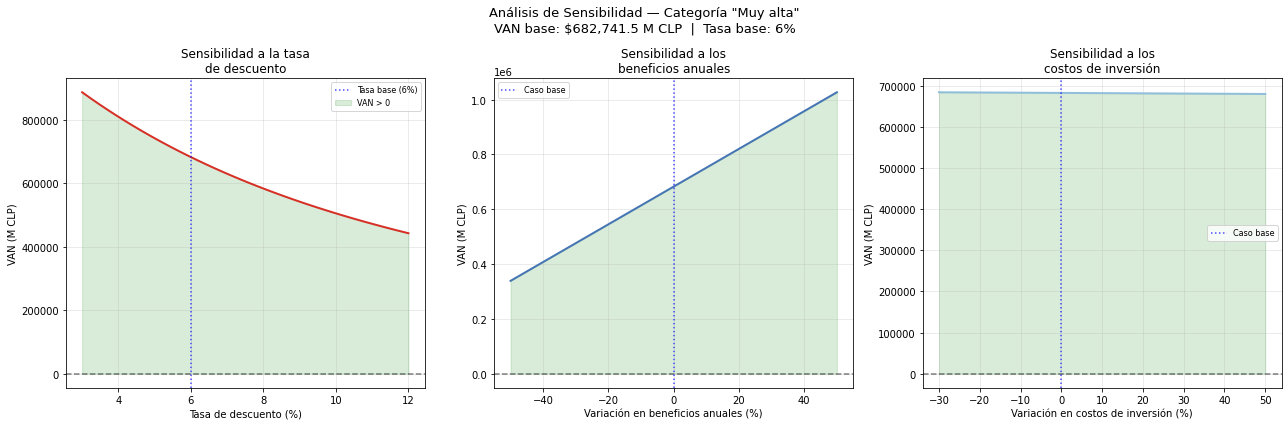

✅ Gráfico de sensibilidad guardado


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA B2 — Análisis de sensibilidad económica                             ║
# ║  CORRECCIÓN: variación de beneficios se aplica sobre el beneficio_anual    ║
# ║  directamente (no sobre longitud como proxy), con documentación explícita. ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Proyecto de referencia: categoría 'Muy alta'
ref_row       = resumen_costos[resumen_costos['prioridad'] == 'Muy alta'].iloc[0]
costo_base    = ref_row['costo_total_clp']
longitud_base = ref_row['longitud_total_km']
res_base      = evaluar_proyecto(costo_base, longitud_base, 'Muy alta')
van_base      = res_base['VAN']
ben_base      = res_base['beneficio_anual']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Análisis de Sensibilidad — Categoría "Muy alta"\n'
    f'VAN base: ${van_base/1e6:,.1f} M CLP  |  Tasa base: {TASA_SOCIAL*100:.0f}%',
    fontsize=13
)

# Panel 1: Tasa de descuento
tasas  = np.linspace(0.03, 0.12, 40)
vans_t = []
for t in tasas:
    flujos = [-costo_base] + [ben_base] * HORIZONTE_ANOS
    vans_t.append(sum(f / (1 + t) ** i for i, f in enumerate(flujos)) / 1e6)

axes[0].plot(tasas * 100, vans_t, color='#d73027', linewidth=2)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].axvline(TASA_SOCIAL * 100, color='blue', linestyle=':', alpha=0.7,
                label=f'Tasa base ({TASA_SOCIAL*100:.0f}%)')
axes[0].fill_between(tasas * 100, vans_t, 0,
                      where=[v > 0 for v in vans_t], alpha=0.15, color='green', label='VAN > 0')
axes[0].set_xlabel('Tasa de descuento (%)'); axes[0].set_ylabel('VAN (M CLP)')
axes[0].set_title('Sensibilidad a la tasa\nde descuento'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Panel 2: Variación en beneficios anuales (escala directa, no proxy de longitud)
factores = np.linspace(0.5, 1.5, 40)
vans_b   = []
for f in factores:
    ben_f  = ben_base * f   # escalado directo del beneficio anual
    flujos = [-costo_base] + [ben_f] * HORIZONTE_ANOS
    vans_b.append(sum(x / (1 + TASA_SOCIAL) ** i for i, x in enumerate(flujos)) / 1e6)

axes[1].plot((factores - 1) * 100, vans_b, color='#4575b4', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='blue', linestyle=':', alpha=0.7, label='Caso base')
axes[1].fill_between((factores-1)*100, vans_b, 0,
                      where=[v > 0 for v in vans_b], alpha=0.15, color='green')
axes[1].set_xlabel('Variación en beneficios anuales (%)'); axes[1].set_ylabel('VAN (M CLP)')
axes[1].set_title('Sensibilidad a los\nbeneficios anuales'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Panel 3: Variación en costos de inversión
factores_c = np.linspace(0.7, 1.5, 40)
vans_c     = []
for f in factores_c:
    flujos = [-costo_base * f] + [ben_base] * HORIZONTE_ANOS
    vans_c.append(sum(x / (1 + TASA_SOCIAL) ** i for i, x in enumerate(flujos)) / 1e6)

axes[2].plot((factores_c - 1) * 100, vans_c, color='#91bfdb', linewidth=2)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[2].axvline(0, color='blue', linestyle=':', alpha=0.7, label='Caso base')
axes[2].fill_between((factores_c-1)*100, vans_c, 0,
                      where=[v > 0 for v in vans_c], alpha=0.15, color='green')
axes[2].set_xlabel('Variación en costos de inversión (%)'); axes[2].set_ylabel('VAN (M CLP)')
axes[2].set_title('Sensibilidad a los\ncostos de inversión'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'sensibilidad_van_{NOMBRE_ARCHIVO}.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico de sensibilidad guardado")


---
### 🎒 Celda B3 — Optimización de portafolio (Heurística Greedy Knapsack)

**Objetivo:** Seleccionar el **conjunto óptimo de proyectos** que maximiza  
el VAN total del portafolio, sujeto a la restricción presupuestaria.

**El problema de la mochila (Knapsack):**  
Dado un presupuesto B y n proyectos con costo c_i y beneficio b_i,  
seleccionar el subconjunto S ⊆ {1,...,n} tal que:

$$\max \sum_{i \in S} b_i \quad \text{s.t.} \quad \sum_{i \in S} c_i \leq B$$

**Algoritmo implementado: Heurística greedy por ratio VAN/Costo**  
Ordena proyectos de mayor a menor ratio VAN/Costo y los selecciona  
mientras haya presupuesto disponible. Complejidad O(n log n).  
*Nota: El problema Knapsack 0/1 exacto es NP-difícil (programación dinámica  
con complejidad O(n×W)); para 2.300+ segmentos la heurística greedy da  
soluciones muy cercanas al óptimo en tiempo O(n log n).*

**Lo que verás:**
- Número de proyectos seleccionados y VAN total del portafolio.
- Distribución del presupuesto por nivel de prioridad (torta + barras).


=== OPTIMIZACIÓN DE PORTAFOLIO (HEURÍSTICA GREEDY VAN/COSTO) ===

Presupuesto disponible     : $2.50 mil millones CLP
Proyectos viables totales  : 4079
Proyectos seleccionados    : 1525
Costo total portafolio     : $2.50 mil millones CLP
Presupuesto no utilizado   : $0.0 M CLP
VAN total del portafolio   : $33.88 mil millones CLP
Ratio B/C portafolio       : 14.55


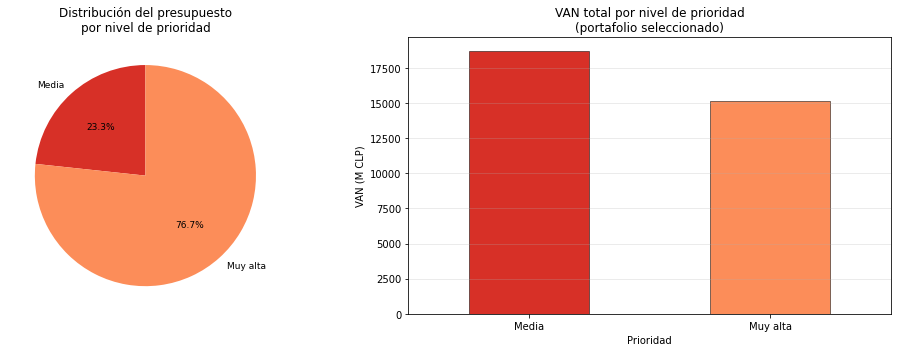


✅ Gráfico de portafolio guardado como 'portafolio_knapsack_san_miguel.png'


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA B3 — Optimización de portafolio (Heurística Greedy por VAN/Costo)  ║
# ║  CORRECCIÓN: docstring corregido — se usa heurística greedy O(n log n),   ║
# ║  NO programación dinámica. El Knapsack 0/1 exacto sería demasiado lento   ║
# ║  para 2.300+ segmentos (necesitaría discretización del presupuesto).       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Candidatos: segmentos de prioridad Muy alta, Alta y Media con costo > 0
proyectos = edges_map[edges_map['prioridad'].isin(['Muy alta', 'Alta', 'Media'])].copy()
proyectos = proyectos.reset_index(drop=True)

# Calcular VAN para cada proyecto individual
resultados_ind = []
for _, row in proyectos.iterrows():
    long_km = row['length_m'] / 1000
    costo   = row['costo_estimado_clp']
    if costo > 0 and long_km > 0:
        r = evaluar_proyecto(costo, long_km, row['prioridad'])
        resultados_ind.append({
            'prioridad':   row['prioridad'],
            'longitud_km': long_km,
            'costo_clp':   costo,
            'VAN':         r['VAN'],
            'TIR_pct':     r['TIR'] * 100,
            'ratio_bc':    r['ratio_bc'],
            'viable':      r['viable'],
        })

df_proy = pd.DataFrame(resultados_ind)
df_proy = df_proy[df_proy['viable'] == True].copy()
df_proy['ratio_van_costo'] = df_proy['VAN'] / df_proy['costo_clp']
df_proy = df_proy.sort_values('ratio_van_costo', ascending=False).reset_index(drop=True)

# ── Heurística greedy (ratio VAN/Costo) ──────────────────────────────────────
presupuesto_rest = PRESUPUESTO_CLP
seleccionados    = []
van_total = costo_total_port = 0

for _, row in df_proy.iterrows():
    if row['costo_clp'] <= presupuesto_rest:
        seleccionados.append(row)
        presupuesto_rest -= row['costo_clp']
        van_total        += row['VAN']
        costo_total_port += row['costo_clp']

df_sel = pd.DataFrame(seleccionados)

print("=== OPTIMIZACIÓN DE PORTAFOLIO (HEURÍSTICA GREEDY VAN/COSTO) ===\n")
print(f"Presupuesto disponible     : ${PRESUPUESTO_CLP/1e9:.2f} mil millones CLP")
print(f"Proyectos viables totales  : {len(df_proy)}")
print(f"Proyectos seleccionados    : {len(df_sel)}")
print(f"Costo total portafolio     : ${costo_total_port/1e9:.2f} mil millones CLP")
print(f"Presupuesto no utilizado   : ${presupuesto_rest/1e6:.1f} M CLP")
print(f"VAN total del portafolio   : ${van_total/1e9:.2f} mil millones CLP")
print(f"Ratio B/C portafolio       : {(van_total + costo_total_port)/costo_total_port:.2f}")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prioridad_costos = df_sel.groupby('prioridad')['costo_clp'].sum() / 1e6
prioridad_costos.plot.pie(ax=axes[0], autopct='%1.1f%%',
                           colors=['#d73027','#fc8d59','#fee090'],
                           startangle=90, fontsize=9)
axes[0].set_title('Distribución del presupuesto\npor nivel de prioridad')
axes[0].set_ylabel('')

van_por_prioridad = df_sel.groupby('prioridad')['VAN'].sum() / 1e6
van_por_prioridad.plot.bar(ax=axes[1], color=['#d73027','#fc8d59','#fee090'],
                            edgecolor='black', linewidth=0.5)
axes[1].set_title('VAN total por nivel de prioridad\n(portafolio seleccionado)')
axes[1].set_xlabel('Prioridad'); axes[1].set_ylabel('VAN (M CLP)')
axes[1].tick_params(axis='x', rotation=0); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
fname_port = f'portafolio_knapsack_{NOMBRE_ARCHIVO}.png'
plt.savefig(fname_port, dpi=130, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico de portafolio guardado como '{fname_port}'")


# Exportación QGIS completa + SHP individual por Grupo

---
## 🗺️ Celda C1 — Exportación QGIS completa + SHP individual por Grupo

**Objetivo:** Generar todos los archivos GIS necesarios para trabajar en QGIS.

**PARTE 1 — GeoPackage multicapa + SHPs globales**

| Archivo | Contenido |
|---|---|
| `ipi_{base}.gpkg` | GeoPackage con 3 capas: red vial IPI, grupos y Metro |
| `shp_global/red_vial_ipi_{base}.shp` | Red vial completa con IPI y costos |
| `shp_global/cuadrantes_grupos.shp` | 11 polígonos de grupos de trabajo |
| `shp_global/estaciones_metro.shp` | Estaciones Metro Línea 2 |

**PARTE 2 — Un SHP por Grupo (Grupos 1–11)**  
Para cada uno de los 11 Grupos de Gran Avenida se genera una subcarpeta con:
- `grupo_NN_red_vial_{base}.shp` → segmentos recortados al cuadrante del grupo
- `grupo_NN_poligono.shp` → polígono límite con estadísticas resumidas

> **Fix CRS:** fiona 1.8.x + pyproj 3.x no acepta el WKT moderno `GEOGCRS[...]`.  
> Esta celda usa `CRS.to_wkt('WKT1_GDAL')` para forzar la versión 1 compatible.  
> Si persiste el error, ejecuta: `pip install fiona --upgrade`


In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA C1 — Exportación QGIS completa + SHP individual por Grupo           ║
# ║                                                                              ║
# ║  PARTE 1 · GeoPackage multicapa (red vial, grupos, metro) + SHPs globales  ║
# ║            en carpeta shp_global/ → arrastrar a QGIS y listo.              ║
# ║                                                                              ║
# ║  PARTE 2 · Clip espacial de la red vial por cada uno de los 11 Grupos de   ║
# ║            Gran Avenida → un SHP independiente en shp_grupos/grupo_XX/      ║
# ║            más el polígono-límite del grupo (para panel de referencia).     ║
# ║                                                                              ║
# ║  FIX CRS · fiona 1.8.x + pyproj 3.x genera WKT moderno (GEOGCRS) que       ║
# ║            fiona no puede parsear. Se fuerza WKT versión 1 (GDAL) que es   ║
# ║            compatible con QGIS ≥ 3.x, ArcGIS ≥ 10.x y fiona 1.8.x.        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import geopandas as gpd
import pandas as pd
from pathlib import Path
from pyproj import CRS as _ProjCRS

# ── Fix de compatibilidad CRS (fiona 1.8.x + pyproj 3.x) ────────────────────
def fix_crs(gdf, epsg=4326):
    """
    Convierte el CRS del GeoDataFrame a WKT versión 1 (GDAL/ESRI),
    que fiona 1.8.x puede parsear correctamente (en vez del WKT moderno
    GEOGCRS que genera pyproj 3.x y causa el error 'Invalid input to create CRS').
    """
    gdf = gdf.copy()
    try:
        wkt1 = _ProjCRS.from_epsg(epsg).to_wkt('WKT1_GDAL')
        gdf.crs = wkt1
    except Exception:
        pass
    return gdf

# ── Helpers de escritura con fallback a GeoJSON ──────────────────────────────
def guardar_capa(gdf, path, label='', epsg=4326):
    """
    Guarda un GeoDataFrame como Shapefile con fix de CRS incorporado.
    Si falla, guarda como GeoJSON (que QGIS lee sin problemas).
    """
    path = Path(path)
    gdf_out = fix_crs(gdf, epsg)
    try:
        gdf_out.to_file(str(path))
        sz = path.stat().st_size / 1024
        print(f"  ✅  {label:55s}  ({sz:,.0f} KB)")
        return True
    except Exception as e_shp:
        alt = path.with_suffix('.geojson')
        try:
            gdf.to_file(str(alt), driver='GeoJSON')
            sz = alt.stat().st_size / 1024
            print(f"  🔶  {label:55s}  → GeoJSON ({sz:,.0f} KB)")
            print(f"       (fiona 1.8 no soportó SHP — ambos formatos abren en QGIS)")
        except Exception as e_json:
            print(f"  ❌  {label}: {e_shp} | fallback GeoJSON: {e_json}")
        return False

def guardar_gpkg(gdf, gpkg_path, layer_name, epsg=4326):
    """Guarda una capa dentro de un GeoPackage con fix de CRS."""
    gdf_out = fix_crs(gdf, epsg)
    try:
        gdf_out.to_file(str(gpkg_path), driver='GPKG', layer=layer_name)
        print(f"  ✅  capa '{layer_name}' ({len(gdf_out):,} registros)")
    except Exception as e:
        print(f"  ⚠️  capa '{layer_name}': {e}")

# ════════════════════════════════════════════════════════════════════════════════
# PARTE 1 — GeoPackage multicapa + Shapefiles globales
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 72)
print("PARTE 1 — GeoPackage multicapa + SHPs globales para QGIS")
print("=" * 72)

# Capa 1: Red vial completa con IPI, prioridad y costo ─────────────────────
capa_red = edges_shp_wgs84.copy()
capa_red['prioridad']    = capa_red['prioridad'].astype(str)
capa_red['intervencion'] = capa_red['intervencion'].astype(str)
capa_red['highway']      = capa_red['highway'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x)
)
# Columna auxiliar en millones CLP (más legible en QGIS)
capa_red['costo_mclp'] = (capa_red['costo_estimado_clp'] / 1e6).round(4)
# Rank numérico para simbología graduada en QGIS (5=más urgente, 1=menos)
orden_ipi = {'Muy alta': 5, 'Alta': 4, 'Media': 3, 'Baja': 2, 'Muy baja': 1}
capa_red['ipi_rank'] = capa_red['prioridad'].map(orden_ipi).fillna(0).astype(int)
print(f"\n[Capa 1] Red vial IPI    : {len(capa_red):,} segmentos")

# Capa 2: 11 cuadrantes de trabajo (ya en WGS84) ──────────────────────────
capa_grupos = gdf_cuadrantes[['grupo', 'numero', 'color', 'geometry']].copy()
capa_grupos['n_segs']     = 0
capa_grupos['long_km']    = 0.0
capa_grupos['costo_mclp'] = 0.0
print(f"[Capa 2] Grupos Gran Av. : {len(capa_grupos)} cuadrantes")

# Capa 3: Estaciones Metro L2 (UTM 32719 → WGS84) ─────────────────────────
capa_metro = gdf_metro.to_crs(epsg=4326).copy()
print(f"[Capa 3] Estaciones Metro: {len(capa_metro)} estaciones")

# GeoPackage multicapa ──────────────────────────────────────────────────────
gpkg_path = f'ipi_{base}.gpkg'
print(f"\n📦  GeoPackage: '{gpkg_path}'")
guardar_gpkg(capa_red,    gpkg_path, 'red_vial_ipi')
guardar_gpkg(capa_grupos, gpkg_path, 'cuadrantes_grupos')
guardar_gpkg(capa_metro,  gpkg_path, 'estaciones_metro')
if Path(gpkg_path).exists():
    sz_gpkg = Path(gpkg_path).stat().st_size / 1024
    print(f"  📦  Tamaño total: {sz_gpkg:,.0f} KB")
    print(f"  👉  QGIS: Capa → Añadir capa → Vectorial → '{gpkg_path}'")

# Shapefiles globales ───────────────────────────────────────────────────────
shp_global_dir = Path('shp_global')
shp_global_dir.mkdir(exist_ok=True)
print(f"\n📁  Shapefiles globales: '{shp_global_dir}/'")
guardar_capa(capa_red,    shp_global_dir / f'red_vial_ipi_{base}.shp',
             f'red_vial_ipi_{base}.shp')
guardar_capa(capa_grupos, shp_global_dir / 'cuadrantes_grupos.shp',
             'cuadrantes_grupos.shp')
guardar_capa(capa_metro,  shp_global_dir / 'estaciones_metro.shp',
             'estaciones_metro.shp')

# ════════════════════════════════════════════════════════════════════════════════
# PARTE 2 — Clip espacial + SHP individual por Grupo
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 72)
print("PARTE 2 — SHP individual por cada Grupo de trabajo (clip espacial)")
print("=" * 72)
print("  Método: gpd.clip() → segmentos que intersectan el polígono del Grupo.\n")

grupos_root = Path('shp_grupos')
grupos_root.mkdir(exist_ok=True)

resumen_grupos = []

for _, grupo_row in gdf_cuadrantes.sort_values('numero').iterrows():
    num   = int(grupo_row['numero'])
    label = grupo_row['grupo']          # 'Grupo 1' … 'Grupo 11'
    color = grupo_row['color']
    poly  = grupo_row['geometry']       # Shapely Polygon WGS84

    grupo_dir = grupos_root / f'grupo_{num:02d}'
    grupo_dir.mkdir(exist_ok=True)

    # Clip espacial ──────────────────────────────────────────────────────────
    try:
        clip_gdf = gpd.clip(capa_red, poly)
        clip_gdf = clip_gdf[
            clip_gdf.geometry.notna() & ~clip_gdf.geometry.is_empty
        ].copy()
    except Exception as e_clip:
        print(f"  ⚠️  {label}: error en clip → {e_clip}")
        clip_gdf = gpd.GeoDataFrame(columns=capa_red.columns, crs=capa_red.crs)

    n_seg   = len(clip_gdf)
    long_km = clip_gdf['length_m'].sum() / 1000 if n_seg > 0 else 0.0
    costo_m = clip_gdf['costo_estimado_clp'].sum() / 1e6 if n_seg > 0 else 0.0
    ipi_med = clip_gdf['IPI'].mean() if n_seg > 0 else 0.0
    n_prio  = clip_gdf['prioridad'].value_counts().to_dict() if n_seg > 0 else {}

    slug = label.lower().replace(' ', '_')        # 'grupo_1'
    shp_red_path  = grupo_dir / f'{slug}_red_vial_{base}.shp'
    shp_poly_path = grupo_dir / f'{slug}_poligono.shp'

    print(f"  ── {label} | {n_seg:>4} segs | {long_km:>6.1f} km "
          f"| ${costo_m:>7,.0f} M CLP | IPI medio={ipi_med:.3f}")

    # Guardar red vial recortada del grupo
    guardar_capa(clip_gdf, shp_red_path,
                 f'  {slug}_red_vial_{base}.shp')

    # Guardar polígono del grupo con estadísticas como atributos
    poly_gdf = gpd.GeoDataFrame(
        [{
            'grupo':       label,
            'numero':      num,
            'color':       color,
            'n_segmentos': n_seg,
            'long_km':     round(long_km, 2),
            'costo_mclp':  round(costo_m, 1),
            'ipi_medio':   round(ipi_med, 4),
            'may_alta':    n_prio.get('Muy alta', 0),
            'alta':        n_prio.get('Alta', 0),
            'media':       n_prio.get('Media', 0),
            'baja':        n_prio.get('Baja', 0),
            'may_baja':    n_prio.get('Muy baja', 0),
        }],
        geometry=[poly],
        crs='EPSG:4326'
    )
    guardar_capa(poly_gdf, shp_poly_path,
                 f'  {slug}_poligono.shp')

    # Enriquecer capa_grupos para el GPKG final
    capa_grupos.loc[capa_grupos['numero'] == num, 'n_segs']     = n_seg
    capa_grupos.loc[capa_grupos['numero'] == num, 'long_km']    = round(long_km, 2)
    capa_grupos.loc[capa_grupos['numero'] == num, 'costo_mclp'] = round(costo_m, 1)

    resumen_grupos.append({
        'Grupo':     label,
        'N° segs':   n_seg,
        'Long. km':  round(long_km, 2),
        'M CLP':     round(costo_m, 1),
        'IPI medio': round(ipi_med, 4),
        'Muy alta':  n_prio.get('Muy alta', 0),
        'Alta':      n_prio.get('Alta', 0),
        'Media':     n_prio.get('Media', 0),
    })

# Actualizar capa_grupos en el GPKG con estadísticas enriquecidas
print(f"\n  → Actualizando 'cuadrantes_grupos' en GeoPackage con estadísticas...")
guardar_gpkg(capa_grupos, gpkg_path, 'cuadrantes_grupos')

# ════════════════════════════════════════════════════════════════════════════════
# RESUMEN FINAL
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 72)
print("RESUMEN — Segmentos viales por Grupo de trabajo")
print("=" * 72)
df_resumen = pd.DataFrame(resumen_grupos)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
print(df_resumen.to_string(index=False))
print("─" * 72)
print(f"  TOTAL  {df_resumen['N° segs'].sum():>6} segs | "
      f"{df_resumen['Long. km'].sum():>7.1f} km | "
      f"${df_resumen['M CLP'].sum():>8,.0f} M CLP")

print(f"""
📂  Estructura de archivos generados
─────────────────────────────────────────────────────────────────────
  ipi_{base}.gpkg                ← GeoPackage multicapa (preferido en QGIS)
                                    Capas: red_vial_ipi · cuadrantes_grupos · estaciones_metro
  shp_global/
    red_vial_ipi_{base}.shp      ← Red vial completa (2.300+ segmentos)
    cuadrantes_grupos.shp         ← 11 polígonos de Grupos de trabajo
    estaciones_metro.shp          ← Estaciones Metro Línea 2

  shp_grupos/
    grupo_01/  grupo_01_red_vial_{base}.shp  +  grupo_01_poligono.shp
    grupo_02/  grupo_02_red_vial_{base}.shp  +  grupo_02_poligono.shp
    ...        (11 carpetas en total)
    grupo_11/  grupo_11_red_vial_{base}.shp  +  grupo_11_poligono.shp

💡  Uso en QGIS:
    • GeoPackage : Capa → Añadir capa → Vectorial → seleccionar .gpkg
    • SHPs       : Capa → Añadir capa → Vectorial → seleccionar .shp
    • Estilo IPI : Simbología → Categorizado → Campo: prioridad
    • Estilo grad.: Simbología → Graduado    → Campo: IPI
    • Color grupo: Simbología → Categorizado → Campo: grupo
─────────────────────────────────────────────────────────────────────
""")

print("✅  Celda C1 completada — exportación QGIS lista.")


PARTE 1 — GeoPackage multicapa + SHPs globales para QGIS

[Capa 1] Red vial IPI    : 6,798 segmentos
[Capa 2] Grupos Gran Av. : 11 cuadrantes
[Capa 3] Estaciones Metro: 9 estaciones

📦  GeoPackage: 'ipi_san_miguel.gpkg'
  ⚠️  capa 'red_vial_ipi': Invalid field type <class 'list'>
  ✅  capa 'cuadrantes_grupos' (11 registros)
  ✅  capa 'estaciones_metro' (9 registros)
  📦  Tamaño total: 124 KB
  👉  QGIS: Capa → Añadir capa → Vectorial → 'ipi_san_miguel.gpkg'

📁  Shapefiles globales: 'shp_global/'
  ❌  red_vial_ipi_san_miguel.shp: Invalid field type <class 'list'> | fallback GeoJSON: Invalid input to create CRS: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUN

  ❌    grupo_8_red_vial_san_miguel.shp: Invalid field type <class 'list'> | fallback GeoJSON: Invalid input to create CRS: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
  ✅    grupo_8_poligono.shp                                   (0 KB)
  ── Grupo 9 | 1033 segs |   42